# <font color="red">**H7: EELS Clustering Challenge**</font>

## Spectral data → EELS clustering and dimensional reduction

An EELS spectrum contains many energy channels, so every pixel can be viewed as a point in a **high-dimensional spectral space**.

Today we will ask:

> **Can we find meaningful groups of EELS spectra, and do we recover the same groups after reducing the dimensionality?**

### Your tasks

1. Explore the EELS spectral dataset.
2. Cluster spectra in the **original high-dimensional space**.
3. Reduce the spectra with **PCA**.
4. Cluster again in the **low-dimensional PCA space**.
5. Compare the two cluster maps.
6. Measure how strongly the cluster assignments overlap.
7. Decide what makes a clustering result **good or bad**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_18_25092026/eels_clustering_hackathon.ipynb)

<h2><font color="purple">1.</font> Load the Dataset</h2>

<p>
Each spatial pixel contains one complete <b>EELS spectrum</b>.
</p>

<p style="font-size:18px;">
(x, y) &rarr; I(E)
</p>

<p>
If the spectral image has dimensions:
</p>

<p style="font-size:18px;">
H &times; W &times; N<sub>E</sub>
</p>

<p>
then:
</p>

<ul>
  <li><b>H</b> = image height</li>
  <li><b>W</b> = image width</li>
  <li><b>N<sub>E</sub></b> = number of energy channels in each spectrum</li>
</ul>

<p>
Therefore, every spatial pixel contains <b>N<sub>E</sub> spectral features</b>.
</p>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.metrics.cluster import contingency_matrix

In [2]:
# Download data in Google Colab
!gdown --fuzzy 1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6

usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--proxy PROXY] [--speed SPEED]
             [--cookies FILE] [--cookies-from-browser BROWSER] [--no-cookies]
             [--no-check-certificate] [--continue] [--folder] [--json]
             [--format FORMAT] [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: --fuzzy


In [4]:
file_name = "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_18_25092026/Plasmonic_sets_hackathon.npy"

raw = np.load(file_name, allow_pickle=True)
loadedfile = raw.tolist()

print("Available datasets:", loadedfile.keys())

Available datasets: dict_keys(['0', '1', '2', '3'])


In [18]:
# Use the same dataset as the previous challenge
data = loadedfile["2"]

image = data["image"]
spectra = data["spectrum image"]
energy = data["energy axis"]
scale   = float(data["scale"])

H, W, N_E = spectra.shape

print("Image:", image.shape)
print("Spectral image:", spectra.shape)
print("Energy axis:", energy.shape)

Image: (33, 63)
Spectral image: (33, 63, 4322)
Energy axis: (4322,)


Noise of one channel in one spectrum: about 14 counts
Main plasmon peak (average spectrum): about 0.56 eV
Peak height of the average spectrum:  about 757 counts



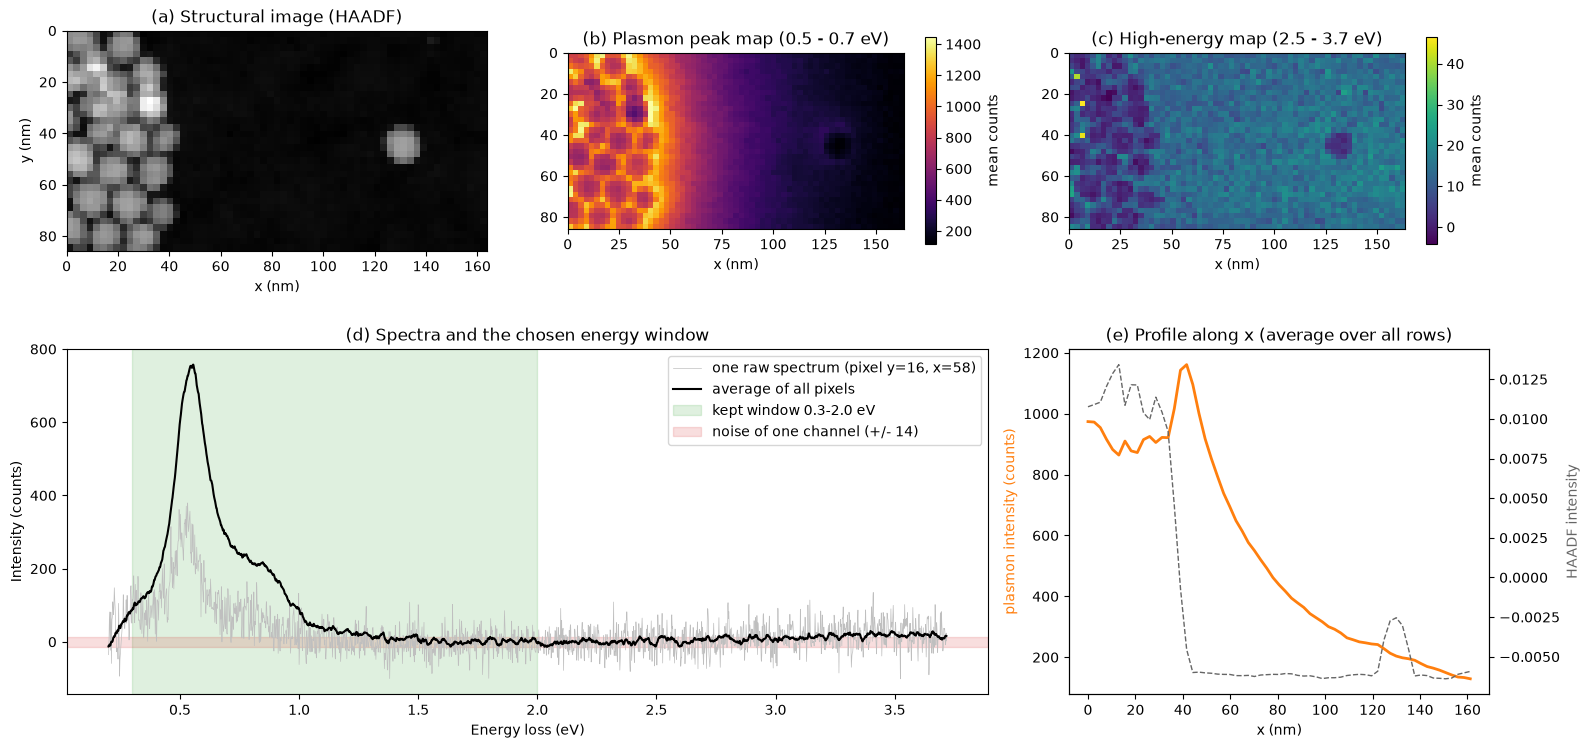

In [20]:
# =====================================================================
# CELL 2: Look at the data before we process it
# =====================================================================
# Goal: find out which part of the energy axis holds REAL signal,
#       so that in the next cell we keep only that part.

#   (a) the structural image      -> where are the particles?
#   (b) the plasmon peak map      -> where is the plasmon signal strong?
#   (c) the high-energy map       -> what is going on above 2.5 eV?
#   (d) the spectra               -> average spectrum, one raw spectrum, our window
#   (e) a line profile            -> does the plasmon signal stop suddenly
#                                    or fade slowly away from the particles?


E_MIN = 0.3   # eV. Below this, the tail of the zero-loss peak is not cleanly removed.
E_MAX = 2.0   # eV. Above this, there is no plasmon signal: only noise and an artifact.

# Turn the spectrum image into a table:
#   one ROW    = one pixel (one spectrum)
#   one COLUMN = one energy channel
X_raw = spectra.reshape(-1, N_E)          # shape (H*W, N_E) = (2079, 4322)

noise_sigma = np.std(np.diff(X_raw, axis=1)) / np.sqrt(2)

mean_spectrum = X_raw.mean(axis=0)        # average spectrum over all pixels
peak_energy = energy[np.argmax(mean_spectrum)]

print(f"Noise of one channel in one spectrum: about {noise_sigma:.0f} counts")
print(f"Main plasmon peak (average spectrum): about {peak_energy:.2f} eV")
print(f"Peak height of the average spectrum:  about {mean_spectrum.max():.0f} counts\n")

def window_map(e_lo, e_hi):
    """Average of all channels between e_lo and e_hi (in eV), for every pixel.
    Returns a 1D array with one value per pixel."""
    inside = (energy >= e_lo) & (energy < e_hi)
    return X_raw[:, inside].mean(axis=1)

peak_map = window_map(0.5, 0.7)           # reference 1: the plasmon peak
haadf    = image.ravel()                  # reference 2: the particles


extent = [0, W * scale, H * scale, 0]

fig, ax = plt.subplot_mosaic(
    [["img", "peak", "high"],
     ["spec", "spec", "prof"]],
    figsize=(16, 8),
)

# (a) Structural image
ax["img"].imshow(image, cmap="gray", extent=extent)
ax["img"].set_title("(a) Structural image (HAADF)")
ax["img"].set_xlabel("x (nm)")
ax["img"].set_ylabel("y (nm)")

# (b) Plasmon peak map
im = ax["peak"].imshow(peak_map.reshape(H, W), cmap="inferno", extent=extent)
ax["peak"].set_title("(b) Plasmon peak map (0.5 - 0.7 eV)")
ax["peak"].set_xlabel("x (nm)")
fig.colorbar(im, ax=ax["peak"], shrink=0.6, label="mean counts")

# (c) High-energy map
im = ax["high"].imshow(window_map(2.5, 3.72).reshape(H, W), cmap="viridis", extent=extent)
ax["high"].set_title("(c) High-energy map (2.5 - 3.7 eV)")
ax["high"].set_xlabel("x (nm)")
fig.colorbar(im, ax=ax["high"], shrink=0.6, label="mean counts")

# (d) Spectra
# One raw spectrum from a pixel far away from the particles (right side, middle row)
y_far, x_far = H // 2, W - 5
ax["spec"].plot(energy, spectra[y_far, x_far], color="0.75", lw=0.5,
                label=f"one raw spectrum (pixel y={y_far}, x={x_far})")
ax["spec"].plot(energy, mean_spectrum, color="k", lw=1.5, label="average of all pixels")
ax["spec"].axvspan(E_MIN, E_MAX, color="tab:green", alpha=0.15,
                   label=f"kept window {E_MIN}-{E_MAX} eV")
ax["spec"].axhspan(-noise_sigma, noise_sigma, color="tab:red", alpha=0.15,
                   label=f"noise of one channel (+/- {noise_sigma:.0f})")
ax["spec"].set_xlabel("Energy loss (eV)")
ax["spec"].set_ylabel("Intensity (counts)")
ax["spec"].set_title("(d) Spectra and the chosen energy window")
ax["spec"].legend(loc="upper right")

# (e) Line profile: average each column of the peak map over all rows
x_nm = np.arange(W) * scale
profile_plasmon = peak_map.reshape(H, W).mean(axis=0)
profile_haadf = image.mean(axis=0)

ax["prof"].plot(x_nm, profile_plasmon, color="tab:orange", lw=2, label="plasmon (0.5 - 0.7 eV)")
ax["prof"].set_xlabel("x (nm)")
ax["prof"].set_ylabel("plasmon intensity (counts)", color="tab:orange")
ax["prof"].set_title("(e) Profile along x (average over all rows)")

# second y-axis for the HAADF profile, because it has different units
ax2 = ax["prof"].twinx()
ax2.plot(x_nm, profile_haadf, color="0.4", lw=1, ls="--", label="HAADF")
ax2.set_ylabel("HAADF intensity", color="0.4")

plt.tight_layout()
plt.show()

Normalization mode: 'area'
Cropped:    2088 channels between 0.3 and 2.0 eV
Binned:     130 bins of 16 channels (~13 meV each)
Noise per bin: about 3.6 counts (was 14 per channel)
Negative values set to zero: 23.0% of all bins
Final data for clustering: X_shape with shape (2079, 130)  (pixels x energy bins)


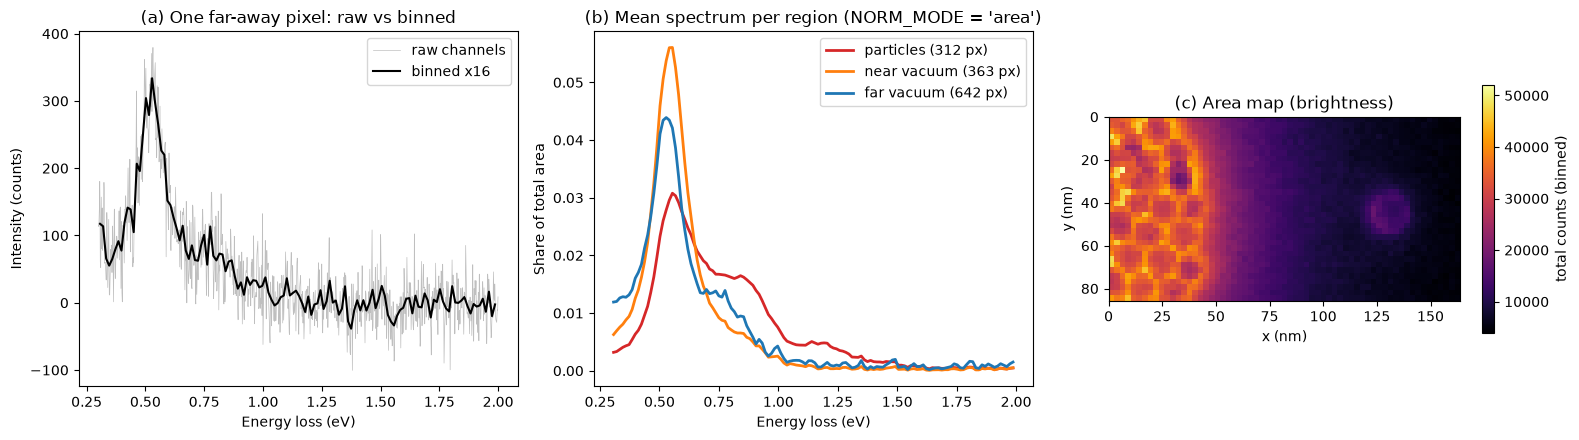

In [74]:
# =====================================================================
# CELL 3: Prepare the spectra (crop -> bin -> clip -> normalize)
# =====================================================================
# Goal: turn 4322 noisy channels into ~130 clean channels for clustering.
#
# Steps:
#   1) Crop:      keep only E_MIN..E_MAX (chosen in Cell 2)
#   2) Bin:       add up groups of neighbouring channels -> less noise
#   3) Clip:      set negative values to zero (needed for NMF in Cell 4)
#   4) Normalize: choose HOW with NORM_MODE below
#
# =====================  THE SWITCH  =====================
# Change only this line, then run all the next cells again. Nothing else to edit.
#   "area" : divide each spectrum by its total area (sum over the window)
#            -> clusters by SHAPE; most robust against noise
#   "peak" : divide each spectrum by the height of the main plasmon peak (~0.55 eV)
#            -> everything is measured RELATIVE to the main mode;
#               higher-energy modes become much more visible
#   "none" : no per-pixel normalization (only one common scale for all pixels)
#            -> clusters by BRIGHTNESS too, i.e. mostly by distance to the particles
NORM_MODE = "area"
# ========================================================

# ---------------------------------------------------------------------
# 1) Crop the energy window
# ---------------------------------------------------------------------
keep = (energy >= E_MIN) & (energy < E_MAX)   # True for channels inside the window
X_crop = X_raw[:, keep]                        # shape (2079, ~2090)
E_crop = energy[keep]

# ---------------------------------------------------------------------
# 2) Bin the energy axis
# ---------------------------------------------------------------------
# One channel is only 0.8 meV wide. A plasmon peak is about 100 meV wide.
# So we can average BIN neighbouring channels and lose no real detail.
# Averaging n channels makes the noise sqrt(n) times smaller (16 -> 4x less noise).
BIN = 16                                       # 16 channels x 0.8 meV = ~13 meV per bin

n_bins = X_crop.shape[1] // BIN                # how many full bins fit
n_use  = n_bins * BIN                          # drop the few leftover channels at the end

# reshape (pixels, n_bins, BIN) and average over the last axis = average inside each bin
X_bin = X_crop[:, :n_use].reshape(-1, n_bins, BIN).mean(axis=2)
E_bin = E_crop[:n_use].reshape(n_bins, BIN).mean(axis=1)   # centre energy of each bin

# ---------------------------------------------------------------------
# 3) Clip negative values
# ---------------------------------------------------------------------
# NMF (next cell) only accepts values >= 0.
# Negative values here are only noise around zero (mostly in the weak
# tail above ~1.3 eV), so setting them to zero changes very little.
share_negative = np.mean(X_bin < 0)
X_pos = np.clip(X_bin, 0, None)

# ---------------------------------------------------------------------
# 4) Normalize (the method is chosen by NORM_MODE at the top of this cell)
# ---------------------------------------------------------------------
# We always keep these two maps, whatever the mode:
area = X_pos.sum(axis=1, keepdims=True)        # total signal of each pixel
area_map = area.reshape(H, W)                  # brightness map

# Main-peak intensity: MEAN over a small window around the peak.
# (Not the single highest bin: with noise, the highest bin is too often a
#  noise spike, especially in weak far-vacuum pixels.)
PEAK_WINDOW = (0.50, 0.60)                     # eV, the peak is ~0.1 eV wide
in_peak = (E_bin >= PEAK_WINDOW[0]) & (E_bin < PEAK_WINDOW[1])
peak_intensity = np.clip(X_pos[:, in_peak].mean(axis=1, keepdims=True), 1e-6, None)
main_peak_map = peak_intensity.reshape(H, W)

if NORM_MODE == "area":
    X_shape = X_pos / area                     # every row sums to 1
    NORM_LABEL = "Share of total area"         # y-axis label used in later plots
elif NORM_MODE == "peak":
    X_shape = X_pos / peak_intensity           # main peak ~ 1 in every pixel
    NORM_LABEL = "Intensity / main-peak intensity"
elif NORM_MODE == "none":
    X_shape = X_pos / np.median(area)          # ONE number for all pixels -> brightness is kept
    NORM_LABEL = "Intensity / median pixel area"
else:
    raise ValueError('NORM_MODE must be "area", "peak" or "none"')

print(f"Normalization mode: {NORM_MODE!r}")
print(f"Cropped:    {X_crop.shape[1]} channels between {E_MIN} and {E_MAX} eV")
print(f"Binned:     {n_bins} bins of {BIN} channels (~{1000 * (E_bin[1] - E_bin[0]):.0f} meV each)")
print(f"Noise per bin: about {noise_sigma / np.sqrt(BIN):.1f} counts (was {noise_sigma:.0f} per channel)")
print(f"Negative values set to zero: {share_negative:.1%} of all bins")
print(f"Final data for clustering: X_shape with shape {X_shape.shape}  (pixels x energy bins)")

# ---------------------------------------------------------------------
# 5) Check: do different regions have different spectra?
# ---------------------------------------------------------------------
# We define three simple regions by hand, only for this check:
#   particles   = the brightest 15% of the HAADF image
#   near vacuum = columns 45 - 75 nm   (just outside the particle cluster)
#   far vacuum  = columns 110 - 160 nm (far away), without the isolated particle
x_nm_grid = np.tile(np.arange(W) * scale, H)          # x position (nm) of every pixel
is_particle = haadf > np.percentile(haadf, 85)
near_vac = (x_nm_grid > 45) & (x_nm_grid < 75) & ~is_particle
far_vac  = (x_nm_grid > 110) & ~is_particle

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) raw vs binned spectrum of ONE pixel -> shows how much binning helps
p = (H // 2) * W + (W - 5)                             # the same far pixel as in Cell 2
ax[0].plot(E_crop, X_crop[p], color="0.75", lw=0.5, label="raw channels")
ax[0].plot(E_bin, X_bin[p], color="k", lw=1.5, label=f"binned x{BIN}")
ax[0].set_title("(a) One far-away pixel: raw vs binned")
ax[0].set_xlabel("Energy loss (eV)")
ax[0].set_ylabel("Intensity (counts)")
ax[0].legend()

# (b) mean normalized spectrum of each region
for mask, name, color in [(is_particle, "particles", "tab:red"),
                          (near_vac, "near vacuum", "tab:orange"),
                          (far_vac, "far vacuum", "tab:blue")]:
    ax[1].plot(E_bin, X_shape[mask].mean(axis=0), color=color, lw=2,
               label=f"{name} ({mask.sum()} px)")
ax[1].set_title(f"(b) Mean spectrum per region (NORM_MODE = {NORM_MODE!r})")
ax[1].set_xlabel("Energy loss (eV)")
ax[1].set_ylabel(NORM_LABEL)
ax[1].legend()

# (c) brightness map (removed by "area" and "peak", kept by "none")
im = ax[2].imshow(area_map, cmap="inferno", extent=extent)
ax[2].set_title("(c) Area map (brightness)")
ax[2].set_xlabel("x (nm)")
ax[2].set_ylabel("y (nm)")
fig.colorbar(im, ax=ax[2], shrink=0.7, label="total counts (binned)")

plt.tight_layout()
plt.show()

# What to see:
#   (a) The binned spectrum is much smoother, but the peak keeps its shape.
#   (b) The three regions look different:
#       - particles:   more weight above ~0.8 eV (higher-energy modes)
#       - near vacuum: sharp, dominant peak at ~0.55 eV
#       - far vacuum:  broader peak, more weight below 0.45 eV
#       With "peak" the high-energy modes stand out most; with "none" the
#       curves differ mostly in HEIGHT (brightness = distance to particles).
#   (c) Brightness mostly tells "how far from the particles".

K = 1:  explained = 0.9374
K = 2:  explained = 0.9750
K = 3:  explained = 0.9834
K = 4:  explained = 0.9854
K = 5:  explained = 0.9869
K = 6:  explained = 0.9878
K = 7:  explained = 0.9885
K = 8:  explained = 0.9890

Using N_COMP = 4
Component peak energies (eV): [0.502 0.554 0.763 0.906]
Sum of weights per pixel: mean 1.001, min 0.853, max 1.077  (should be close to 1)


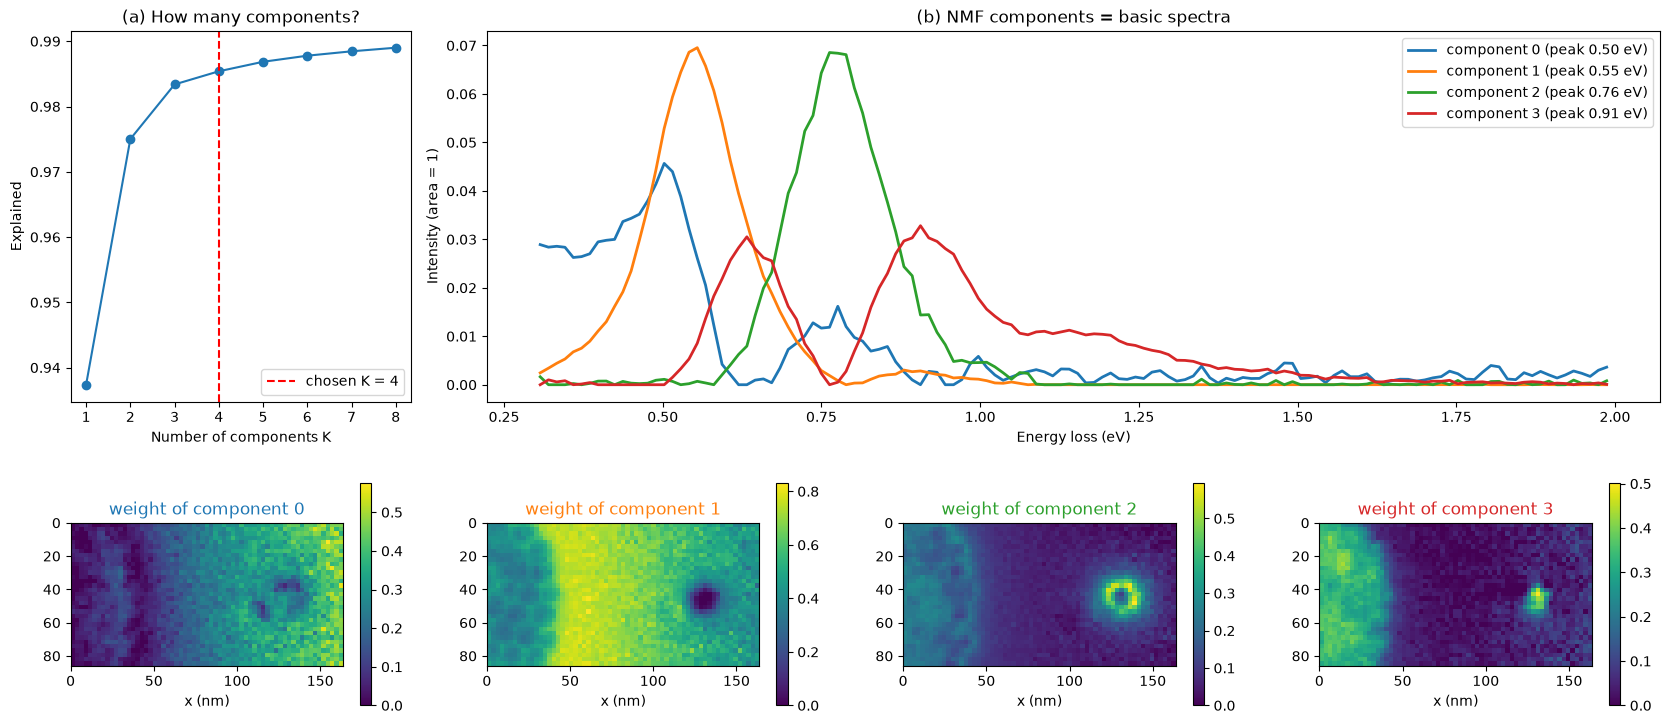

In [75]:
# NMF = Non-negative Matrix Factorization. "Non-negative" means all components
# and all weights are >= 0. This is physical: EELS intensities add up,
# they never cancel each other. (PCA does not have this rule, so PCA
# components can have negative parts that are hard to interpret.)
SEED = 0
rng = np.random.default_rng(SEED)

from sklearn.decomposition import NMF
import warnings

# NMF sometimes warns that it needs more iterations for large K.
# The result is still fine for our purpose, so we hide this warning.
warnings.filterwarnings("ignore", message="Maximum number of iterations")

# ---------------------------------------------------------------------
# 1) How many components do we need?
# ---------------------------------------------------------------------
# We try K = 1 ... 8 and measure how well NMF rebuilds the data.
# "explained" = 1 - (error of NMF) / (error of just using zero)  -> 1.0 is perfect.
# When adding one more component stops helping much, we have enough.
K_values = range(1, 9)
explained = []
for K in K_values:
    nmf_test = NMF(n_components=K, init="nndsvda", max_iter=2000, random_state=SEED)
    Z_test = nmf_test.fit_transform(X_shape)
    X_rebuilt = Z_test @ nmf_test.components_
    explained.append(1 - np.sum((X_shape - X_rebuilt) ** 2) / np.sum(X_shape ** 2))
    print(f"K = {K}:  explained = {explained[-1]:.4f}")

# ---------------------------------------------------------------------
# 2) Final NMF with our chosen K
# ---------------------------------------------------------------------
N_COMP =4   # our choice (see the printed numbers and the plot below)

nmf = NMF(n_components=N_COMP, init="nndsvda", max_iter=2000, random_state=SEED)
Z = nmf.fit_transform(X_shape)        # weights, shape (2079, N_COMP)  <- latent space
C = nmf.components_                   # basic spectra, shape (N_COMP, 130)

# ---------------------------------------------------------------------
# 3) Make the result easy to read
# ---------------------------------------------------------------------
comp_area = C.sum(axis=1)             # area of each component
C = C / comp_area[:, None]            # every component now has area 1
Z = Z * comp_area[None, :]            # weights take the scale -> product Z @ C is unchanged

# (b) NMF gives components in a random order.
peak_E = E_bin[np.argmax(C, axis=1)]
order = np.argsort(peak_E)
C = C[order]            # reorder the basic spectra
Z = Z[:, order]         # reorder the weight columns in the same way
peak_E = peak_E[order]

print(f"\nUsing N_COMP = {N_COMP}")
print("Component peak energies (eV):", np.round(peak_E, 3))
print(f"Sum of weights per pixel: mean {Z.sum(axis=1).mean():.3f}, "
      f"min {Z.sum(axis=1).min():.3f}, max {Z.sum(axis=1).max():.3f}  (should be close to 1)")

# ---------------------------------------------------------------------
# 4) Plots
# ---------------------------------------------------------------------
# top row: (a) + (b); bottom row: one weight map per component
top_row = ["err"] + ["comp"] * (N_COMP - 1)
bottom_row = [f"m{k}" for k in range(N_COMP)]
fig, ax = plt.subplot_mosaic([top_row, bottom_row], figsize=(4.2 * N_COMP, 8))

# (a) explained vs K
ax["err"].plot(list(K_values), explained, "o-")
ax["err"].axvline(N_COMP, color="r", ls="--", label=f"chosen K = {N_COMP}")
ax["err"].set_xlabel("Number of components K")
ax["err"].set_ylabel("Explained")
ax["err"].set_title("(a) How many components?")
ax["err"].legend()

# (b) the basic spectra
colors = plt.cm.tab10(np.arange(N_COMP))
for k in range(N_COMP):
    ax["comp"].plot(E_bin, C[k], color=colors[k], lw=2,
                    label=f"component {k} (peak {peak_E[k]:.2f} eV)")
ax["comp"].set_xlabel("Energy loss (eV)")
ax["comp"].set_ylabel("Intensity (area = 1)")
ax["comp"].set_title("(b) NMF components = basic spectra")
ax["comp"].legend()

# (c) one weight map per component
for k in range(N_COMP):
    a = ax[f"m{k}"]
    im = a.imshow(Z[:, k].reshape(H, W), cmap="viridis", extent=extent, vmin=0)
    a.set_title(f"weight of component {k}", color=colors[k])
    a.set_xlabel("x (nm)")
    fig.colorbar(im, ax=a, shrink=0.6)

plt.tight_layout()
plt.show()

# What to see:
#   (a) The curve rises fast and flattens after K = 3 ("knee").
#       We take K = 4 because the 4th component is a real, new mode
#       (the ring around the isolated particle, see below).
#       Try N_COMP = 3 and N_COMP = 5 yourself and compare.
#   (b) + (c) On this

N_CLUSTERS = 2:  BIC =     -27046
N_CLUSTERS = 3:  BIC =     -28696
N_CLUSTERS = 4:  BIC =     -29532
N_CLUSTERS = 5:  BIC =     -30663
N_CLUSTERS = 6:  BIC =     -30955
N_CLUSTERS = 7:  BIC =     -31079
N_CLUSTERS = 8:  BIC =     -31152
N_CLUSTERS = 9:  BIC =     -31197

GMM with 5 classes:
  pixels per class:   [669 592 223  99 496]
  boundary fraction:  0.100   (lower = smoother map)
  mean uncertainty:   0.112   (max possible = 1.609)


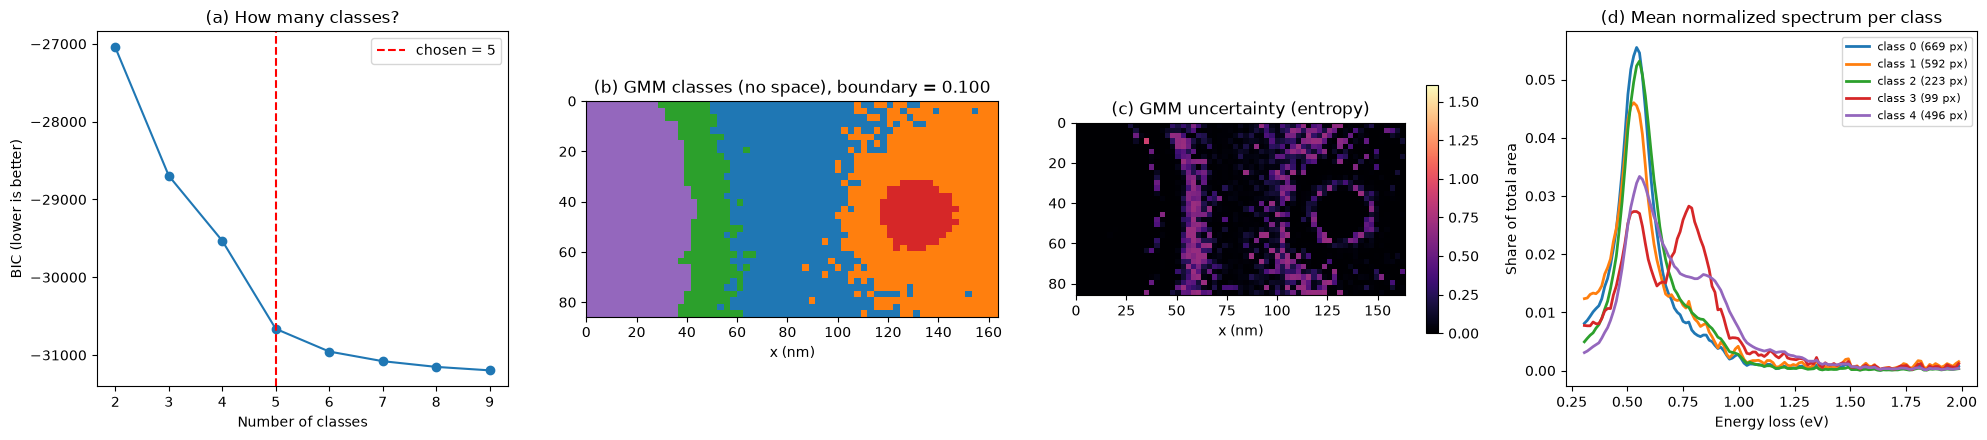

In [78]:

# Gaussian Mixture Model (GMM):
#   - We assume there are N_CLUSTERS groups ("classes").
#   - Each class is a cloud of points in the latent space Z (N_COMP numbers
#     per pixel). The cloud has a centre (mean) and a shape (covariance).
#   - For each pixel, GMM gives the PROBABILITY of each class.
#
# Important: GMM looks at every pixel ALONE. It does not know that
# neighbouring pixels usually belong to the same region. The MRF will add this.
#
# Why we need this cell:
#   1) It is the baseline the MRF must beat.
#   2) Its class means and covariances are the START for the MRF.

from sklearn.mixture import GaussianMixture

# ---------------------------------------------------------------------
# 1) How many classes? Use the BIC score
# ---------------------------------------------------------------------
n_list = range(2, 10)
bic = []
for n in n_list:
    gmm_test = GaussianMixture(n_components=n, covariance_type="full",
                               n_init=5, random_state=SEED)
    gmm_test.fit(Z)
    bic.append(gmm_test.bic(Z))
    print(f"N_CLUSTERS = {n}:  BIC = {bic[-1]:10.0f}")

# ---------------------------------------------------------------------
# 2) Final GMM with our chosen number of classes
# ---------------------------------------------------------------------
N_CLUSTERS = 5    # our choice (see BIC and the maps). Try other values too!

gmm = GaussianMixture(n_components=N_CLUSTERS, covariance_type="full",
                      n_init=10, random_state=SEED)
gmm.fit(Z)

prob_gmm   = gmm.predict_proba(Z)          # shape (2079, N_CLUSTERS): probability of each class
labels_gmm = prob_gmm.argmax(axis=1)       # the most likely class of each pixel

class_order = np.argsort(gmm.means_[:, -1])
relabel = np.empty(N_CLUSTERS, dtype=int)
relabel[class_order] = np.arange(N_CLUSTERS)
labels_gmm = relabel[labels_gmm]
prob_gmm   = prob_gmm[:, class_order]
means_gmm  = gmm.means_[class_order]         # class centres   -> start for the MRF
covs_gmm   = gmm.covariances_[class_order]   # class shapes    -> start for the MRF
weights_gmm = gmm.weights_[class_order]      # class sizes     -> start for the MRF

# ---------------------------------------------------------------------
# 3) Two simple numbers to describe a label map
# ---------------------------------------------------------------------
def boundary_fraction(label_map):
    """Share of neighbour pairs (left-right and up-down) that have DIFFERENT labels.
    Low value = large smooth regions. High value = noisy, 'salt-and-pepper' map."""
    diff_x = label_map[:, 1:] != label_map[:, :-1]   # compare each pixel with its right neighbour
    diff_y = label_map[1:, :] != label_map[:-1, :]   # compare each pixel with the pixel below
    return (diff_x.sum() + diff_y.sum()) / (diff_x.size + diff_y.size)

def label_entropy(prob):
    """Uncertainty of each pixel, from its class probabilities.
    0 = the model is sure. log(N_CLUSTERS) = the model has no idea."""
    p = np.clip(prob, 1e-12, 1)
    return -(p * np.log(p)).sum(axis=1)

map_gmm = labels_gmm.reshape(H, W)
entropy_gmm = label_entropy(prob_gmm).reshape(H, W)

print(f"\nGMM with {N_CLUSTERS} classes:")
print(f"  pixels per class:   {np.bincount(labels_gmm, minlength=N_CLUSTERS)}")
print(f"  boundary fraction:  {boundary_fraction(map_gmm):.3f}   (lower = smoother map)")
print(f"  mean uncertainty:   {entropy_gmm.mean():.3f}   (max possible = {np.log(N_CLUSTERS):.3f})")

# ---------------------------------------------------------------------
# 4) Plots
# ---------------------------------------------------------------------
cmap_cls = plt.get_cmap("tab10", 10)          # fixed colours: class k always has the same colour

fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))

# (a) BIC curve
ax[0].plot(list(n_list), bic, "o-")
ax[0].axvline(N_CLUSTERS, color="r", ls="--", label=f"chosen = {N_CLUSTERS}")
ax[0].set_xlabel("Number of classes")
ax[0].set_ylabel("BIC (lower is better)")
ax[0].set_title("(a) How many classes?")
ax[0].legend()

# (b) GMM label map
ax[1].imshow(map_gmm, cmap=cmap_cls, vmin=-0.5, vmax=9.5, extent=extent, interpolation="nearest")
ax[1].set_title(f"(b) GMM classes (no space), boundary = {boundary_fraction(map_gmm):.3f}")
ax[1].set_xlabel("x (nm)")

# (c) GMM uncertainty map
im = ax[2].imshow(entropy_gmm, cmap="magma", vmin=0, vmax=np.log(N_CLUSTERS), extent=extent)
ax[2].set_title("(c) GMM uncertainty (entropy)")
ax[2].set_xlabel("x (nm)")
fig.colorbar(im, ax=ax[2], shrink=0.7)

# (d) mean spectrum of each class (normalized spectra from Cell 3)
for k in range(N_CLUSTERS):
    ax[3].plot(E_bin, X_shape[labels_gmm == k].mean(axis=0), color=cmap_cls(k), lw=2,
               label=f"class {k} ({np.sum(labels_gmm == k)} px)")
ax[3].set_xlabel("Energy loss (eV)")
ax[3].set_ylabel("Share of total area")
ax[3].set_title("(d) Mean normalized spectrum per class")
ax[3].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [79]:
# =====================================================================
# CELL 6: The hidden Markov Random Field (HMRF) - define the functions
# =====================================================================
# The model has two parts:
#
#   1) DATA part (same as GMM):
#      each class k is a Gaussian cloud in the latent space Z.
#      "How well does pixel i fit class k?"  ->  log N(z_i | mean_k, cov_k)
#
#   2) SPACE part (the new thing = Potts prior):
#      "Neighbouring pixels like to have the SAME class."
#      Every neighbour that has class k gives a bonus of beta to class k.
#
#   Together, for one pixel i:
#
#     score(k) = log N(z_i | mean_k, cov_k)      <- fits the data?
#              + log(weight_k)                   <- how common is class k?
#              + beta * (number of 4 neighbours with class k)   <- agrees with neighbours?
#
#     beta = 0     -> no space at all -> we get back the GMM of Cell 5
#     beta large   -> very smooth map; small regions may disappear
#
# How we find the labels: GIBBS SAMPLING
#   - Go through the pixels. For each pixel, turn the scores into probabilities
#     and DRAW a random class from them (not just take the best one).
#   - Repeat many times ("sweeps"). The maps we draw are samples from the
#     posterior: likely maps appear often, unlikely maps appear rarely.
#   - Counting how often each pixel got each class gives its probability.
#     This gives us an UNCERTAINTY map for free (the main reason to use
#     sampling instead of just picking the best label).
#
# How we learn the class clouds: EM (Expectation - Maximization)
#   E-step: run Gibbs sampling -> probability of each class for each pixel
#   M-step: recompute each class mean and covariance with these probabilities
#   Repeat a few times.

from scipy.stats import multivariate_normal
from sklearn.metrics import adjusted_rand_score
import time

# ---------------------------------------------------------------------
# 1) Data part: log-probability of every pixel under every class
# ---------------------------------------------------------------------
def log_emission(Z, means, covs):
    """Returns array (n_pixels, n_classes): log N(z_i | mean_k, cov_k)."""
    n_classes = len(means)
    out = np.empty((Z.shape[0], n_classes))
    for k in range(n_classes):
        out[:, k] = multivariate_normal.logpdf(Z, mean=means[k], cov=covs[k],
                                               allow_singular=True)
    return out

# ---------------------------------------------------------------------
# 2) Space part: count neighbours of each class
# ---------------------------------------------------------------------
def neighbour_counts(label_map, n_classes):
    """For every pixel and every class k: how many of its 4 neighbours
    (up, down, left, right) have class k. Returns array (H, W, n_classes)."""
    one_hot = np.eye(n_classes)[label_map]                  # (H, W, K): 1 at the pixel's class
    padded = np.pad(one_hot, ((1, 1), (1, 1), (0, 0)))      # zeros around the image border
    return (padded[:-2, 1:-1] + padded[2:, 1:-1]            # neighbour above + below
            + padded[1:-1, :-2] + padded[1:-1, 2:])         # neighbour left  + right

# Checkerboard trick for speed:
# "white" pixels only touch "black" pixels (with 4 neighbours).
# So we can update ALL white pixels at the same time, then ALL black pixels.
yy, xx = np.indices((H, W))
checkerboard = [(yy + xx) % 2 == 0, (yy + xx) % 2 == 1]

def gibbs_sweep(label_map, log_em_map, log_weights, beta, rng):
    """One full Gibbs sweep over the image (white pixels, then black pixels)."""
    n_classes = log_em_map.shape[2]
    for mask in checkerboard:
        score = (log_em_map + log_weights
                 + beta * neighbour_counts(label_map, n_classes))   # (H, W, K)
        # Draw a class from the probabilities exp(score) / sum(exp(score)).
        # "Gumbel-max trick": add random Gumbel noise and take the maximum.
        # This is an exact and fast way to draw from these probabilities.
        drawn = np.argmax(score + rng.gumbel(size=score.shape), axis=2)
        label_map = np.where(mask, drawn, label_map)     # update only this colour
    return label_map

def run_gibbs(log_em, log_weights, beta, labels_start, n_sweeps, n_burn, rng):
    """Run many sweeps. The first n_burn sweeps are thrown away ("burn-in",
    the chain needs time to forget its start). From the rest we count how
    often each pixel had each class -> probabilities.
    Returns: prob (n_pixels, K) and the last label map (n_pixels,)."""
    n_classes = log_em.shape[1]
    log_em_map = log_em.reshape(H, W, n_classes)
    label_map = labels_start.reshape(H, W).copy()
    counts = np.zeros((H, W, n_classes))
    for sweep in range(n_sweeps):
        label_map = gibbs_sweep(label_map, log_em_map, log_weights, beta, rng)
        if sweep >= n_burn:
            counts += np.eye(n_classes)[label_map]
    prob = counts / (n_sweeps - n_burn)
    return prob.reshape(-1, n_classes), label_map.ravel()

# ---------------------------------------------------------------------
# 3) The full model: EM + Gibbs
# ---------------------------------------------------------------------
def fit_hmrf(Z, beta, means, covs, weights, labels_start,
             n_em=10, n_sweeps=60, n_burn=20,
             n_sweeps_final=300, n_burn_final=100,
             seed=SEED, verbose=False):
    """Fit the hidden MRF for one value of beta.
    Starts from the GMM result (means, covs, weights, labels_start).
    Returns a dictionary with labels, probabilities, entropy and class parameters."""
    rng = np.random.default_rng(seed)
    n_classes, n_dim = means.shape
    means, covs, weights = means.copy(), covs.copy(), weights.copy()
    labels = labels_start.copy()
    tiny = 1e-6 * np.eye(n_dim)          # small number on the diagonal keeps covariances stable

    for it in range(n_em):
        # ---- E-step: Gibbs sampling with the current class clouds ----
        log_em = log_emission(Z, means, covs)
        prob, labels = run_gibbs(log_em, np.log(weights), beta, labels, n_sweeps, n_burn, rng)

        # ---- M-step: update every class cloud with the probabilities ----
        Nk = prob.sum(axis=0)                           # "soft" number of pixels in each class
        for k in range(n_classes):
            if Nk[k] < n_dim + 1:                       # class almost empty -> keep old values
                continue
            means[k] = prob[:, k] @ Z / Nk[k]
            diff = Z - means[k]
            covs[k] = (prob[:, k, None] * diff).T @ diff / Nk[k] + tiny
        weights = np.clip(Nk / Nk.sum(), 1e-6, None)    # never exactly 0 (log(0) = -inf)
        weights /= weights.sum()

        if verbose:
            print(f"  EM step {it + 1:2d}: pixels per class = {np.round(Nk).astype(int)}")

    # ---- Final long Gibbs run with the learned clouds -> good probabilities ----
    log_em = log_emission(Z, means, covs)
    prob, _ = run_gibbs(log_em, np.log(weights), beta, labels,
                        n_sweeps_final, n_burn_final, rng)
    labels_final = prob.argmax(axis=1)   # most probable class of each pixel

    return {"beta": beta, "labels": labels_final, "prob": prob,
            "entropy": label_entropy(prob), "means": means, "covs": covs,
            "weights": weights}

# ---------------------------------------------------------------------
# 4) Sanity check: with beta = 0 the HMRF must give back the GMM
# ---------------------------------------------------------------------
t0 = time.time()
test = fit_hmrf(Z, beta=0.0, means=means_gmm, covs=covs_gmm,
                weights=weights_gmm, labels_start=labels_gmm)
print(f"beta = 0 check: agreement with GMM (ARI) = "
      f"{adjusted_rand_score(labels_gmm, test['labels']):.3f}  (should be high, > 0.9)")
# Why not exactly 1? EM re-learns the class clouds a little, and Gibbs
# sampling is random, so a few border pixels can switch class.
print(f"one fit took {time.time() - t0:.1f} s")

beta = 0 check: agreement with GMM (ARI) = 0.914  (should be high, > 0.9)
one fit took 0.7 s


  EM step  1: pixels per class = [667 598 221  97 496]
  EM step  2: pixels per class = [678 597 211  96 496]
  EM step  3: pixels per class = [683 597 207  96 496]
  EM step  4: pixels per class = [684 601 204  94 496]
  EM step  5: pixels per class = [690 600 200  94 495]
  EM step  6: pixels per class = [694 600 197  94 495]
  EM step  7: pixels per class = [697 599 193  94 495]
  EM step  8: pixels per class = [701 598 190  95 495]
  EM step  9: pixels per class = [704 597 189  95 494]
  EM step 10: pixels per class = [702 601 188  94 494]
done in 0.7 s

                            GMM     HMRF
boundary fraction         0.100    0.045   (lower = smoother)
mean uncertainty          0.112    0.036

pixels per class  GMM : [669 592 223  99 496]
pixels per class  HMRF: [703 604 184  93 495]

Agreement GMM vs HMRF (ARI): 0.861
Pixels that changed class:   113 of 2079 (5.4%)


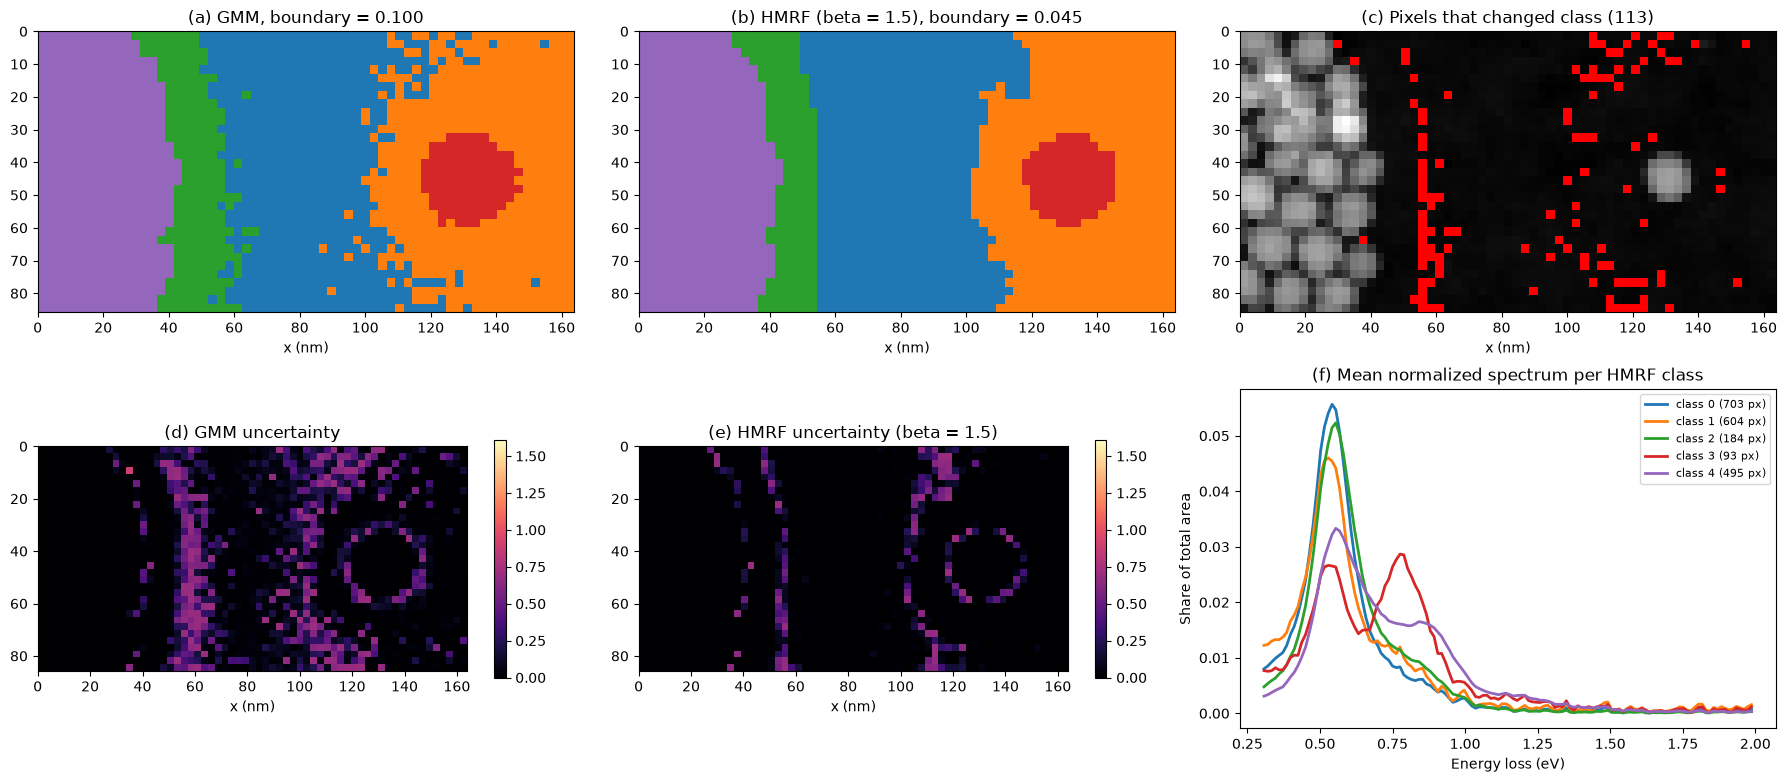

In [80]:
# =====================================================================
# CELL 7: Run the HMRF for one beta and compare with the GMM
# =====================================================================
BETA = 1.5   # a medium value. We scan many values in the next cell.

t0 = time.time()
hmrf = fit_hmrf(Z, beta=BETA, means=means_gmm, covs=covs_gmm,
                weights=weights_gmm, labels_start=labels_gmm, verbose=True)
print(f"done in {time.time() - t0:.1f} s\n")

map_hmrf = hmrf["labels"].reshape(H, W)
entropy_hmrf = hmrf["entropy"].reshape(H, W)
changed = map_hmrf != map_gmm            # True where HMRF and GMM disagree

# ---------------------------------------------------------------------
# 1) Numbers: GMM vs HMRF
# ---------------------------------------------------------------------
print(f"{'':22s} {'GMM':>8s} {'HMRF':>8s}")
print(f"{'boundary fraction':22s} {boundary_fraction(map_gmm):8.3f} {boundary_fraction(map_hmrf):8.3f}   (lower = smoother)")
print(f"{'mean uncertainty':22s} {entropy_gmm.mean():8.3f} {entropy_hmrf.mean():8.3f}")
print(f"\npixels per class  GMM : {np.bincount(labels_gmm, minlength=N_CLUSTERS)}")
print(f"pixels per class  HMRF: {np.bincount(hmrf['labels'], minlength=N_CLUSTERS)}")
print(f"\nAgreement GMM vs HMRF (ARI): {adjusted_rand_score(labels_gmm, hmrf['labels']):.3f}")
print(f"Pixels that changed class:   {changed.sum()} of {H * W} ({changed.mean():.1%})")

# ---------------------------------------------------------------------
# 2) Plots
# ---------------------------------------------------------------------
fig, ax = plt.subplot_mosaic(
    [["gmm", "hmrf", "diff"],
     ["ent_gmm", "ent_hmrf", "spec"]],
    figsize=(18, 8),
)

def show_labels(a, label_map, title):
    """Draw a class map with fixed colours (class k always has the same colour)."""
    a.imshow(label_map, cmap=cmap_cls, vmin=-0.5, vmax=9.5, extent=extent, interpolation="nearest")
    a.set_title(title)
    a.set_xlabel("x (nm)")

show_labels(ax["gmm"], map_gmm, f"(a) GMM, boundary = {boundary_fraction(map_gmm):.3f}")
show_labels(ax["hmrf"], map_hmrf, f"(b) HMRF (beta = {BETA}), boundary = {boundary_fraction(map_hmrf):.3f}")

# (c) where did the class change? Grey image + red pixels on top
ax["diff"].imshow(image, cmap="gray", extent=extent)
ax["diff"].imshow(np.ma.masked_where(~changed, changed), cmap="autumn", extent=extent,
                  interpolation="nearest")
ax["diff"].set_title(f"(c) Pixels that changed class ({changed.sum()})")
ax["diff"].set_xlabel("x (nm)")

# (d) + (e) uncertainty maps with the same colour scale -> fair comparison
for key, ent, title in [("ent_gmm", entropy_gmm, "(d) GMM uncertainty"),
                        ("ent_hmrf", entropy_hmrf, f"(e) HMRF uncertainty (beta = {BETA})")]:
    im = ax[key].imshow(ent, cmap="magma", vmin=0, vmax=np.log(N_CLUSTERS), extent=extent)
    ax[key].set_title(title)
    ax[key].set_xlabel("x (nm)")
    fig.colorbar(im, ax=ax[key], shrink=0.7)

# (f) mean spectrum of each HMRF class (normalized spectra from Cell 3)
for k in range(N_CLUSTERS):
    sel = hmrf["labels"] == k
    if sel.any():
        ax["spec"].plot(E_bin, X_shape[sel].mean(axis=0), color=cmap_cls(k), lw=2,
                        label=f"class {k} ({sel.sum()} px)")
ax["spec"].set_xlabel("Energy loss (eV)")
ax["spec"].set_ylabel("Share of total area")
ax["spec"].set_title("(f) Mean normalized spectrum per HMRF class")
ax["spec"].legend(fontsize=8)

plt.tight_layout()
plt.show()


Isolated-particle class = 3 (GMM size: 99 px)

beta =  0.00 | boundary 0.101 | uncertainty 0.102 | classes 5 | iso particle 102 px | ARI vs GMM 0.914
beta =  0.25 | boundary 0.079 | uncertainty 0.078 | classes 5 | iso particle 101 px | ARI vs GMM 0.904
beta =  0.50 | boundary 0.064 | uncertainty 0.064 | classes 5 | iso particle  98 px | ARI vs GMM 0.882
beta =  0.75 | boundary 0.058 | uncertainty 0.054 | classes 5 | iso particle  95 px | ARI vs GMM 0.870
beta =  1.00 | boundary 0.054 | uncertainty 0.046 | classes 5 | iso particle  95 px | ARI vs GMM 0.872
beta =  1.50 | boundary 0.045 | uncertainty 0.036 | classes 5 | iso particle  93 px | ARI vs GMM 0.861
beta =  2.00 | boundary 0.043 | uncertainty 0.027 | classes 5 | iso particle  93 px | ARI vs GMM 0.855
beta =  3.00 | boundary 0.040 | uncertainty 0.015 | classes 5 | iso particle  94 px | ARI vs GMM 0.836
beta =  4.00 | boundary 0.039 | uncertainty 0.015 | classes 5 | iso particle  76 px | ARI vs GMM 0.831
beta =  6.00 | boundary 0.

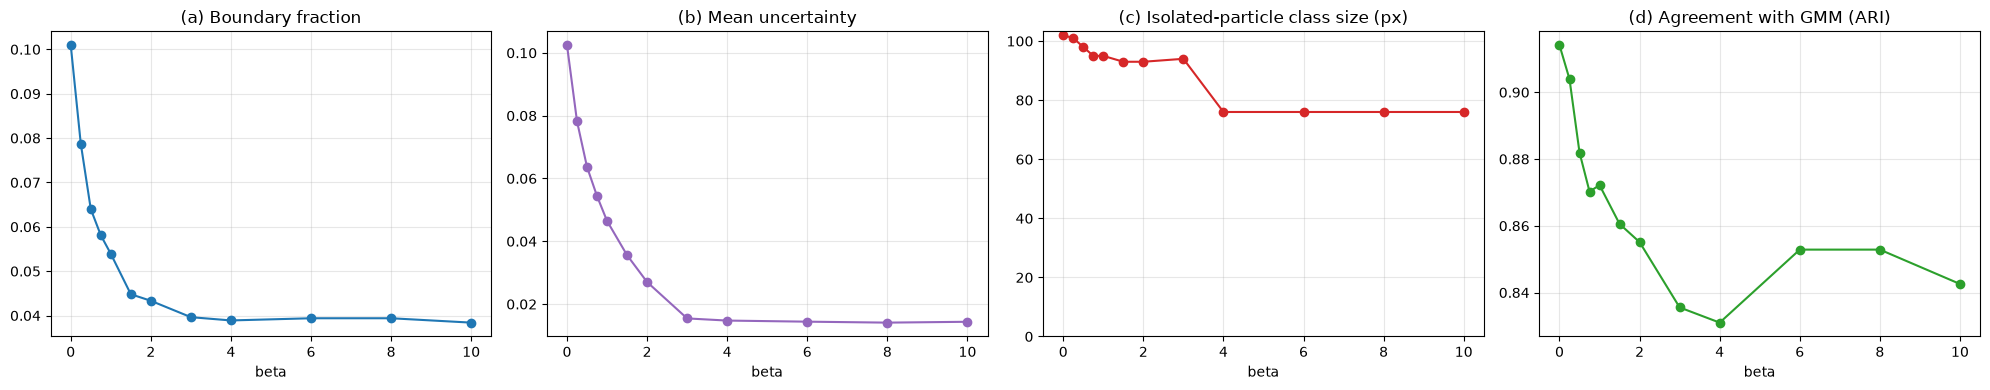

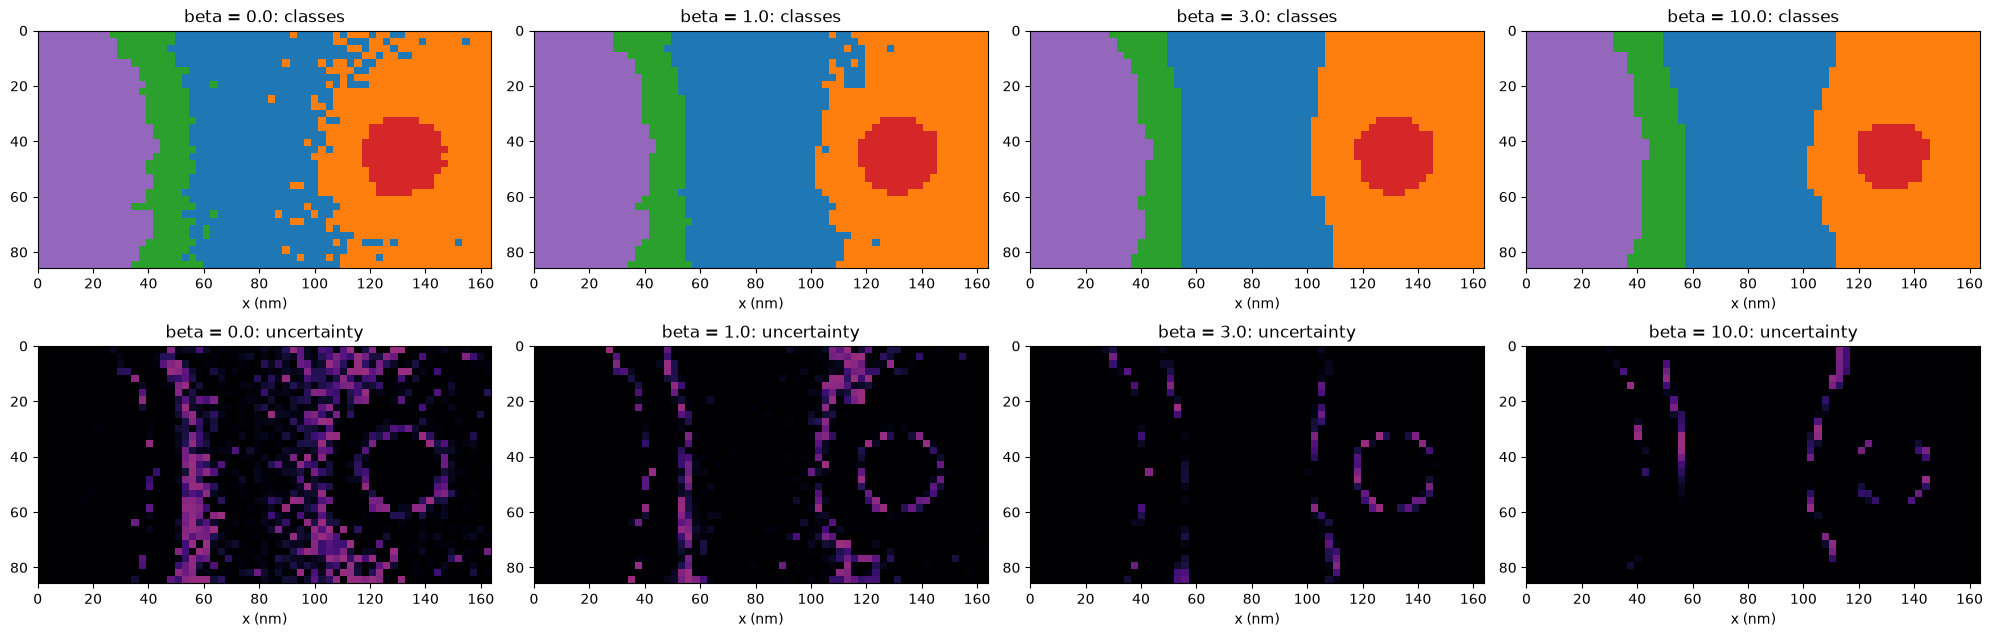


Borders at beta = 2.0:
    border | length (px) | uncertainty on border |   jump
------------------------------------------------------------
   0 - 1   |          53 |                 0.255 |   4.73
   0 - 2   |          35 |                 0.206 |   4.64
   1 - 3   |          44 |                 0.185 |   4.28
   2 - 4   |          44 |                 0.097 |   8.76


In [81]:
# =====================================================================
# CELL 8: Scan beta - a "phase diagram" of the segmentation
# =====================================================================

BETAS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0]

# Which class is the isolated particle? It is the class with the most
# NMF component 2 (the 0.76 eV ring mode, see Cell 4).
iso_class = int(np.argmax(means_gmm[:, 2]))
print(f"Isolated-particle class = {iso_class} "
      f"(GMM size: {np.sum(labels_gmm == iso_class)} px)\n")

results = []
t0 = time.time()
for b in BETAS:
    r = fit_hmrf(Z, beta=b, means=means_gmm, covs=covs_gmm,
                 weights=weights_gmm, labels_start=labels_gmm)
    counts = np.bincount(r["labels"], minlength=N_CLUSTERS)
    r["boundary"] = boundary_fraction(r["labels"].reshape(H, W))
    r["mean_entropy"] = r["entropy"].mean()
    r["n_alive"] = int(np.sum(counts >= 10))
    r["iso_size"] = int(counts[iso_class])
    r["ari_gmm"] = adjusted_rand_score(labels_gmm, r["labels"])
    results.append(r)
    print(f"beta = {b:5.2f} | boundary {r['boundary']:.3f} | uncertainty {r['mean_entropy']:.3f} | "
          f"classes {r['n_alive']} | iso particle {r['iso_size']:3d} px | ARI vs GMM {r['ari_gmm']:.3f}")
print(f"\nscan took {time.time() - t0:.1f} s")

# ---------------------------------------------------------------------
# 1) Curves vs beta
# ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
b_arr = np.array(BETAS)

ax[0].plot(b_arr, [r["boundary"] for r in results], "o-")
ax[0].set_title("(a) Boundary fraction")
ax[1].plot(b_arr, [r["mean_entropy"] for r in results], "o-", color="tab:purple")
ax[1].set_title("(b) Mean uncertainty")
ax[2].plot(b_arr, [r["iso_size"] for r in results], "o-", color="tab:red")
ax[2].set_title("(c) Isolated-particle class size (px)")
ax[2].set_ylim(bottom=0)
ax[3].plot(b_arr, [r["ari_gmm"] for r in results], "o-", color="tab:green")
ax[3].set_title("(d) Agreement with GMM (ARI)")
for a in ax:
    a.set_xlabel("beta")
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2) Label maps for a few beta values
# ---------------------------------------------------------------------
show_betas = [0.0, 1.0, 3.0, 10.0]
fig, ax = plt.subplots(2, len(show_betas), figsize=(5 * len(show_betas), 6.5))
for j, b in enumerate(show_betas):
    r = results[BETAS.index(b)]
    show_labels(ax[0, j], r["labels"].reshape(H, W), f"beta = {b}: classes")
    ax[1, j].imshow(r["entropy"].reshape(H, W), cmap="magma", vmin=0,
                    vmax=np.log(N_CLUSTERS), extent=extent)
    ax[1, j].set_title(f"beta = {b}: uncertainty")
    ax[1, j].set_xlabel("x (nm)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3) Which borders are REAL interfaces, and which are arbitrary cuts?
# ---------------------------------------------------------------------
BETA_BEST = 2.0
r = results[BETAS.index(BETA_BEST)]
lab = r["labels"].reshape(H, W)
ent = r["entropy"].reshape(H, W)

def spread(cov):
    """Typical size of a class cloud: square root of the mean variance."""
    return np.sqrt(np.trace(cov) / cov.shape[0])

print(f"\nBorders at beta = {BETA_BEST}:")
print(f"{'border':>10} | {'length (px)':>11} | {'uncertainty on border':>21} | {'jump':>6}")
print("-" * 60)
for a_cls in range(N_CLUSTERS):
    for b_cls in range(a_cls + 1, N_CLUSTERS):
        # pixels of class a that have a neighbour of class b, and the other way round
        on_border = np.zeros((H, W), dtype=bool)
        pair_x = ((lab[:, :-1] == a_cls) & (lab[:, 1:] == b_cls)) | ((lab[:, :-1] == b_cls) & (lab[:, 1:] == a_cls))
        pair_y = ((lab[:-1, :] == a_cls) & (lab[1:, :] == b_cls)) | ((lab[:-1, :] == b_cls) & (lab[1:, :] == a_cls))
        on_border[:, :-1] |= pair_x
        on_border[:, 1:] |= pair_x
        on_border[:-1, :] |= pair_y
        on_border[1:, :] |= pair_y
        length = pair_x.sum() + pair_y.sum()
        if length < 5:            # these two classes do not really touch
            continue
        dist = np.linalg.norm(r["means"][a_cls] - r["means"][b_cls])
        jump = dist / np.sqrt((spread(r["covs"][a_cls]) ** 2 + spread(r["covs"][b_cls]) ** 2) / 2)
        print(f"{a_cls:>4} - {b_cls:<3} | {length:11d} | {ent[on_border].mean():21.3f} | {jump:6.2f}")

grid    graph: mean number of neighbours =   3.9, colours needed = 5
latent  graph: mean number of neighbours =  37.4, colours needed = 23
hybrid  graph: mean number of neighbours =  39.9, colours needed = 24

Latent edges that are also image neighbours (<= 1.5 px): 6%
Median image distance between latent neighbours:          9.0 px (23 nm)

beta = 1.5
  graph | boundary | uncertainty | iso particle | ARI vs GMM | ARI vs grid
---------------------------------------------------------------------------
   grid |    0.044 |       0.034 |        93 px |      0.859 |       1.000
 latent |    0.104 |       0.002 |        68 px |      0.826 |       0.829
 hybrid |    0.101 |       0.003 |        68 px |      0.829 |       0.833
    GMM |    0.100 |       0.112 |        99 px |      1.000 |


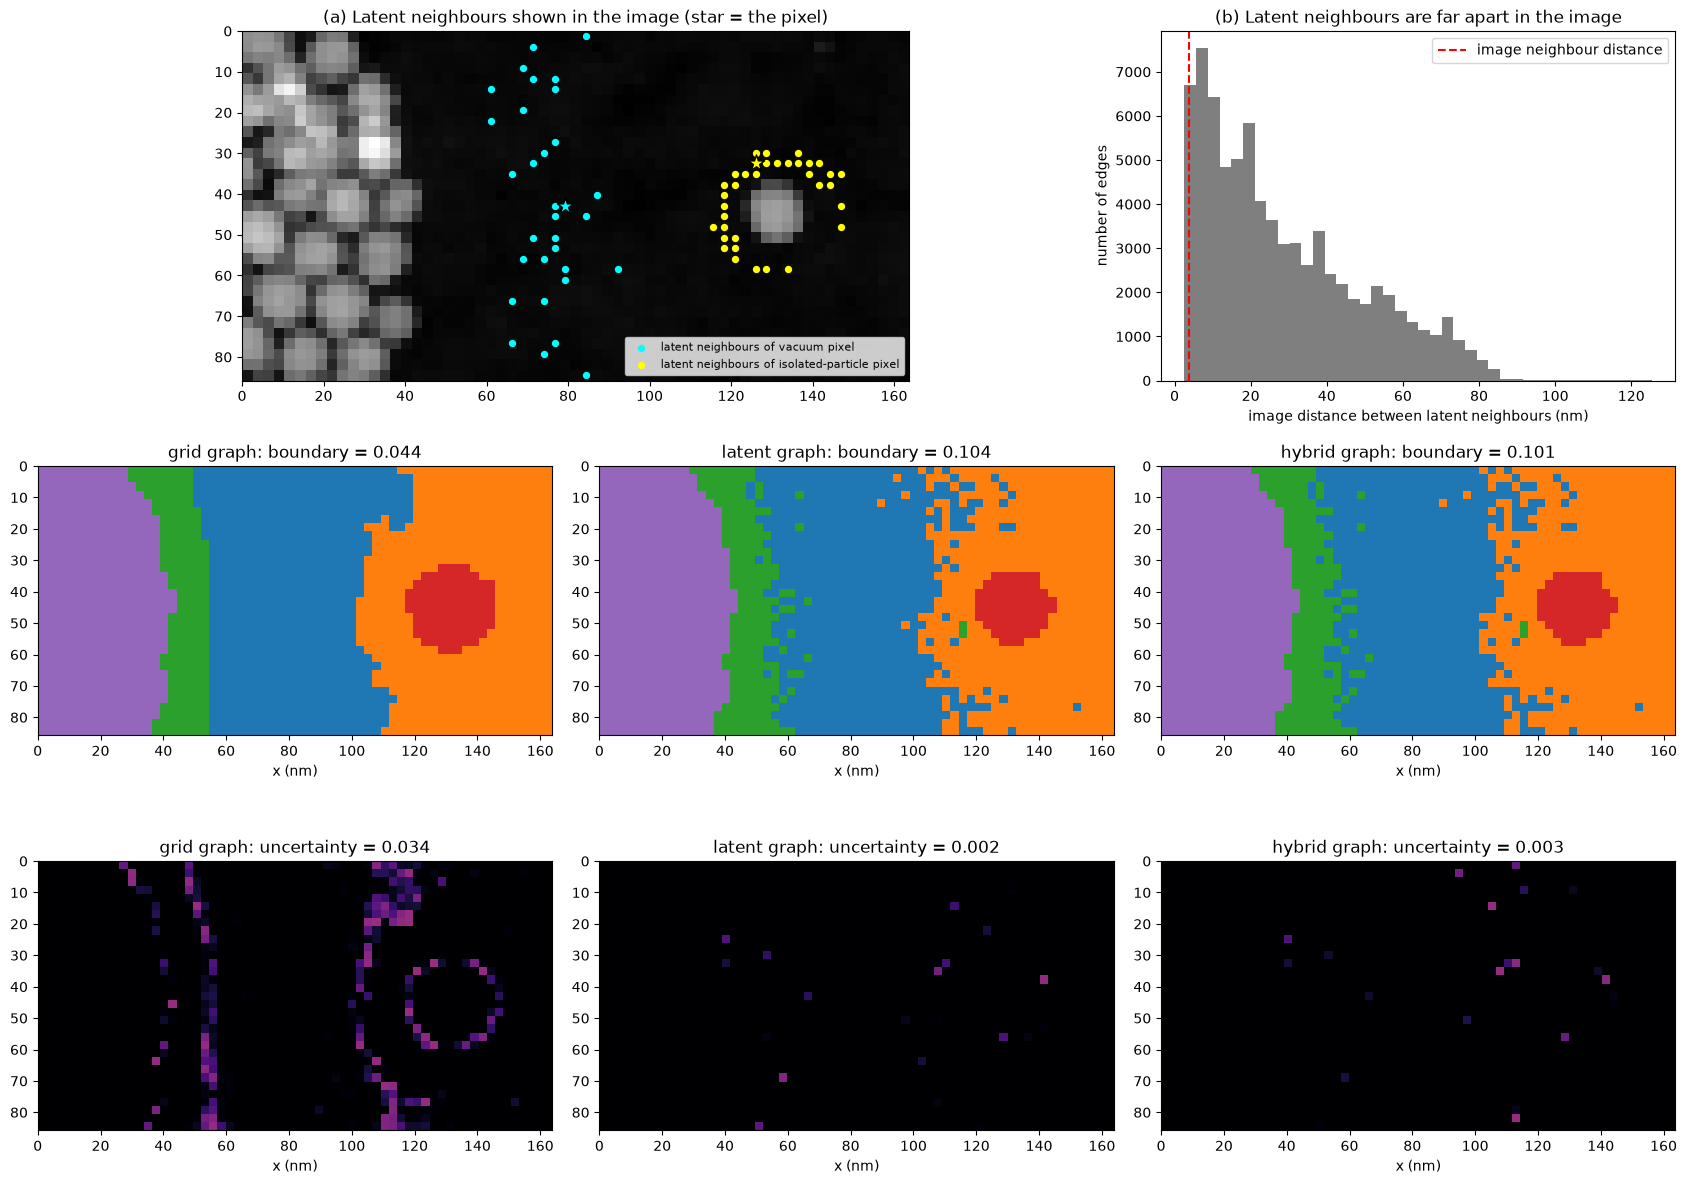

In [82]:
# =====================================================================
# CELL 9: MRF on a graph built in the LATENT space
# =====================================================================
# Until now, "neighbours" = the 4 pixels next to each other in the IMAGE.
# Now we build the graph in the LATENT space Z instead:
#   "neighbours" of pixel i = the K_LATENT pixels whose NMF weights z are
#   closest to z_i, no matter WHERE they are in the image.
#
# The Potts rule stays the same: neighbours like to have the same class.
# We compare three graphs with the same model and the same beta:
#   (1) grid    : image neighbours (same as Cells 6-8)
#   (2) latent  : k-nearest neighbours in Z
#   (3) hybrid  : both kinds of edges together
#
# Technical change: with a general graph, the checkerboard trick does not
# work any more. Instead we COLOUR the graph: give each pixel a colour so
# that no two connected pixels have the same colour. Then all pixels of one
# colour can be updated at the same time (they do not touch each other).

from scipy import sparse
from sklearn.neighbors import kneighbors_graph

# ---------------------------------------------------------------------
# 1) Build the graphs as sparse "adjacency matrices"
# ---------------------------------------------------------------------
# A[i, j] = 1 if pixel i and pixel j are neighbours, else 0.
# A @ one_hot(labels) then gives, for every pixel, how many neighbours
# have each class (the same thing neighbour_counts did for the grid).

def grid_graph(H, W):
    """4-neighbour graph of the image (up, down, left, right)."""
    idx = np.arange(H * W).reshape(H, W)
    rows = np.concatenate([idx[:, :-1].ravel(), idx[:-1, :].ravel()])   # pixel
    cols = np.concatenate([idx[:, 1:].ravel(), idx[1:, :].ravel()])     # its right / lower neighbour
    A = sparse.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(H * W, H * W))
    return (A + A.T).tocsr()                 # make it symmetric: i~j means j~i

def latent_knn_graph(Z, k):
    """Connect every pixel to its k closest pixels in the latent space Z."""
    A = kneighbors_graph(Z, n_neighbors=k, mode="connectivity", include_self=False)
    return A.maximum(A.T).tocsr()            # symmetric: keep the edge if EITHER side chose it

def colour_graph(A):
    """Greedy colouring: every pixel gets the smallest colour that none of
    its neighbours has. Returns a list: for each colour, the pixels with it."""
    n = A.shape[0]
    colours = -np.ones(n, dtype=int)
    degree = np.diff(A.indptr)               # number of neighbours of each pixel
    for i in np.argsort(-degree):            # start with the most connected pixels
        neighbour_colours = set(colours[A.indices[A.indptr[i]:A.indptr[i + 1]]].tolist())
        c = 0
        while c in neighbour_colours:
            c += 1
        colours[i] = c
    return [np.where(colours == c)[0] for c in range(colours.max() + 1)]

K_LATENT = 30                                # number of latent neighbours per pixel

A_grid   = grid_graph(H, W)
A_latent = latent_knn_graph(Z, K_LATENT)
A_hybrid = ((A_grid + A_latent) > 0).astype(float).tocsr()

graphs = {"grid": A_grid, "latent": A_latent, "hybrid": A_hybrid}
for name, A in graphs.items():
    print(f"{name:7s} graph: mean number of neighbours = {A.sum(axis=1).mean():5.1f}, "
          f"colours needed = {len(colour_graph(A))}")
# Note: the grid needs only 2 colours (a checkerboard). Greedy colouring is
# not perfect and finds a few more. That only costs a little speed.

# How far apart IN THE IMAGE are latent neighbours?
rows_l, cols_l = A_latent.nonzero()
dist_px = np.hypot(rows_l // W - cols_l // W, rows_l % W - cols_l % W)
print(f"\nLatent edges that are also image neighbours (<= 1.5 px): {np.mean(dist_px <= 1.5):.0%}")
print(f"Median image distance between latent neighbours:          {np.median(dist_px):.1f} px "
      f"({np.median(dist_px) * scale:.0f} nm)\n")

# ---------------------------------------------------------------------
# 2) The same HMRF as Cell 6, but for ANY graph
# ---------------------------------------------------------------------
def fit_hmrf_graph(Z, beta, A, means, covs, weights, labels_start,
                   n_em=10, n_sweeps=60, n_burn=20,
                   n_sweeps_final=300, n_burn_final=100, seed=SEED):
    """Hidden MRF with Gibbs sampling + EM on a general graph A."""
    rng = np.random.default_rng(seed)
    n_classes, n_dim = means.shape
    groups = colour_graph(A)                     # pixels that can be updated together
    A_rows = [A[g] for g in groups]              # pre-cut rows of A for speed
    means, covs, weights = means.copy(), covs.copy(), weights.copy()
    labels = labels_start.copy()

    def gibbs(log_em, log_w, labels, n_sw, n_bu):
        counts = np.zeros((len(labels), n_classes))
        for sweep in range(n_sw):
            for g, A_g in zip(groups, A_rows):
                n_same = A_g @ np.eye(n_classes)[labels]            # neighbours per class
                score = log_em[g] + log_w + beta * n_same
                labels[g] = np.argmax(score + rng.gumbel(size=score.shape), axis=1)
            if sweep >= n_bu:
                counts[np.arange(len(labels)), labels] += 1
        return counts / (n_sw - n_bu), labels

    for it in range(n_em):
        # E-step
        prob, labels = gibbs(log_emission(Z, means, covs), np.log(weights),
                             labels, n_sweeps, n_burn)
        # M-step
        Nk = prob.sum(axis=0)
        for k in range(n_classes):
            if Nk[k] < n_dim + 1:
                continue
            means[k] = prob[:, k] @ Z / Nk[k]
            diff = Z - means[k]
            covs[k] = (prob[:, k, None] * diff).T @ diff / Nk[k] + 1e-6 * np.eye(n_dim)
        weights = np.clip(Nk / Nk.sum(), 1e-6, None)
        weights /= weights.sum()

    prob, _ = gibbs(log_emission(Z, means, covs), np.log(weights),
                    labels, n_sweeps_final, n_burn_final)
    return {"labels": prob.argmax(axis=1), "prob": prob,
            "entropy": label_entropy(prob), "means": means, "covs": covs}

# ---------------------------------------------------------------------
# 3) Run all three graphs with the same beta
# ---------------------------------------------------------------------
BETA_GRAPH = 1.5
graph_results = {}
print(f"beta = {BETA_GRAPH}")
print(f"{'graph':>7} | {'boundary':>8} | {'uncertainty':>11} | {'iso particle':>12} | {'ARI vs GMM':>10} | {'ARI vs grid':>11}")
print("-" * 75)
for name, A in graphs.items():
    r = fit_hmrf_graph(Z, BETA_GRAPH, A, means_gmm, covs_gmm, weights_gmm, labels_gmm)
    graph_results[name] = r
    print(f"{name:>7} | {boundary_fraction(r['labels'].reshape(H, W)):8.3f} | "
          f"{r['entropy'].mean():11.3f} | {np.sum(r['labels'] == iso_class):9d} px | "
          f"{adjusted_rand_score(labels_gmm, r['labels']):10.3f} | "
          f"{adjusted_rand_score(graph_results['grid']['labels'], r['labels']):11.3f}")
print(f"{'GMM':>7} | {boundary_fraction(map_gmm):8.3f} | {entropy_gmm.mean():11.3f} | "
      f"{np.sum(labels_gmm == iso_class):9d} px |      1.000 |")

# ---------------------------------------------------------------------
# 4) Plots
# ---------------------------------------------------------------------
fig, ax = plt.subplot_mosaic(
    [["nbr", "nbr", "hist"],
     ["lab_grid", "lab_latent", "lab_hybrid"],
     ["ent_grid", "ent_latent", "ent_hybrid"]],
    figsize=(17, 12),
)

# (a) Where are the latent neighbours of two example pixels in the image?
examples = {"vacuum pixel": (H // 2) * W + 30,                     # middle of the vacuum
            "isolated-particle pixel": int(np.flatnonzero(labels_gmm == iso_class)[0])}
ax["nbr"].imshow(image, cmap="gray", extent=extent)
for (name, p), col in zip(examples.items(), ["cyan", "yellow"]):
    nb = A_latent[p].indices                                        # its latent neighbours
    ax["nbr"].scatter((nb % W + 0.5) * scale, (nb // W + 0.5) * scale, s=18, color=col,
                      label=f"latent neighbours of {name}")
    ax["nbr"].scatter((p % W + 0.5) * scale, (p // W + 0.5) * scale, s=150, marker="*",
                      color=col, edgecolor="k")
ax["nbr"].set_title("(a) Latent neighbours shown in the image (star = the pixel)")
ax["nbr"].legend(fontsize=8, loc="lower right")

# (b) Histogram of image distance between latent neighbours
ax["hist"].hist(dist_px * scale, bins=40, color="tab:gray")
ax["hist"].axvline(1.5 * scale, color="r", ls="--", label="image neighbour distance")
ax["hist"].set_xlabel("image distance between latent neighbours (nm)")
ax["hist"].set_ylabel("number of edges")
ax["hist"].set_title("(b) Latent neighbours are far apart in the image")
ax["hist"].legend()

# (c) label maps and (d) uncertainty maps for the three graphs
for name in graphs:
    r = graph_results[name]
    show_labels(ax[f"lab_{name}"], r["labels"].reshape(H, W),
                f"{name} graph: boundary = {boundary_fraction(r['labels'].reshape(H, W)):.3f}")
    im = ax[f"ent_{name}"].imshow(r["entropy"].reshape(H, W), cmap="magma", vmin=0,
                                  vmax=np.log(N_CLUSTERS), extent=extent)
    ax[f"ent_{name}"].set_title(f"{name} graph: uncertainty = {r['entropy'].mean():.3f}")
    ax[f"ent_{name}"].set_xlabel("x (nm)")

plt.tight_layout()
plt.show()


In [83]:
# =====================================================================
# CELL 9b: Latent graph where the interaction DEPENDS ON DISTANCE
# =====================================================================
#
#     w_ij = exp( - d_ij^2 / (sigma_i * sigma_j) )
#
#   sigma_i = distance from pixel i to its k-th neighbour ("local scale").
#   In dense parts of Z, sigma is small; in sparse parts, sigma is large.
#   So "close" is measured relative to the local density of points.
#   (This is the "self-tuning" kernel of Zelnik-Manor & Perona, 2004.)
#
# The Potts term becomes:  beta * sum over neighbours j with class k of w_ij
# fit_hmrf_graph from Cell 9 already does this: A_g @ one_hot sums the weights.

def latent_knn_graph_weighted(Z, k):
    """k-nearest-neighbour graph in Z with Gaussian weights (local scaling)."""
    D = kneighbors_graph(Z, n_neighbors=k, mode="distance", include_self=False)  # D[i, j] = distance
    sigma = D.max(axis=1).toarray().ravel()          # distance to the k-th neighbour of each pixel
    D = D.tocoo()
    w = np.exp(-D.data ** 2 / (sigma[D.row] * sigma[D.col]))
    A = sparse.coo_matrix((w, (D.row, D.col)), shape=D.shape).tocsr()
    return A.maximum(A.T)                            # symmetric

A_latent_w = latent_knn_graph_weighted(Z, K_LATENT)

# Weighted edges are weaker than 1, so the total coupling per pixel is smaller.
# To compare fairly, we print the mean total weight per pixel.
for name, A in {"grid": A_grid, "latent (w = 1)": A_latent, "latent (weighted)": A_latent_w}.items():
    print(f"{name:18s}: mean total edge weight per pixel = {A.sum(axis=1).mean():5.2f}")

r_w = fit_hmrf_graph(Z, BETA_GRAPH, A_latent_w, means_gmm, covs_gmm, weights_gmm, labels_gmm)
print(f"\nweighted latent graph, beta = {BETA_GRAPH}:")
print(f"  boundary {boundary_fraction(r_w['labels'].reshape(H, W)):.3f} | "
      f"uncertainty {r_w['entropy'].mean():.3f} | "
      f"iso particle {np.sum(r_w['labels'] == iso_class)} px | "
      f"ARI vs grid {adjusted_rand_score(graph_results['grid']['labels'], r_w['labels']):.3f}")

grid              : mean total edge weight per pixel =  3.91
latent (w = 1)    : mean total edge weight per pixel = 37.39
latent (weighted) : mean total edge weight per pixel = 18.54

weighted latent graph, beta = 1.5:
  boundary 0.106 | uncertainty 0.003 | iso particle 96 px | ARI vs grid 0.848


r=1 (4 nb)            : neighbours per pixel (inside the image) = 4
r=2 (12 nb)           : neighbours per pixel (inside the image) = 12
r=2.3 (20 nb)         : neighbours per pixel (inside the image) = 20
r=2 (12 nb) + latent  : neighbours per pixel (inside the image) = 12

scan took 12 s

                 graph | beta=0.5  | beta=1.5  | beta=3.0  | beta=4.0  | beta=6.0 
------------------------------------------------------------------------------------------
            r=1 (4 nb) |     0.065 |     0.044 |     0.040 |     0.039 |     0.038   <- boundary
           r=2 (12 nb) |     0.067 |     0.045 |     0.039 |     0.038 |     0.037   <- boundary
         r=2.3 (20 nb) |     0.066 |     0.046 |     0.040 |     0.039 |     0.038   <- boundary
  r=2 (12 nb) + latent |     0.072 |     0.051 |     0.041 |     0.040 |     0.040   <- boundary

            r=1 (4 nb) |        98 |        93 |        97 |        87 |        73   <- iso px
           r=2 (12 nb) |        96 |        91 |  

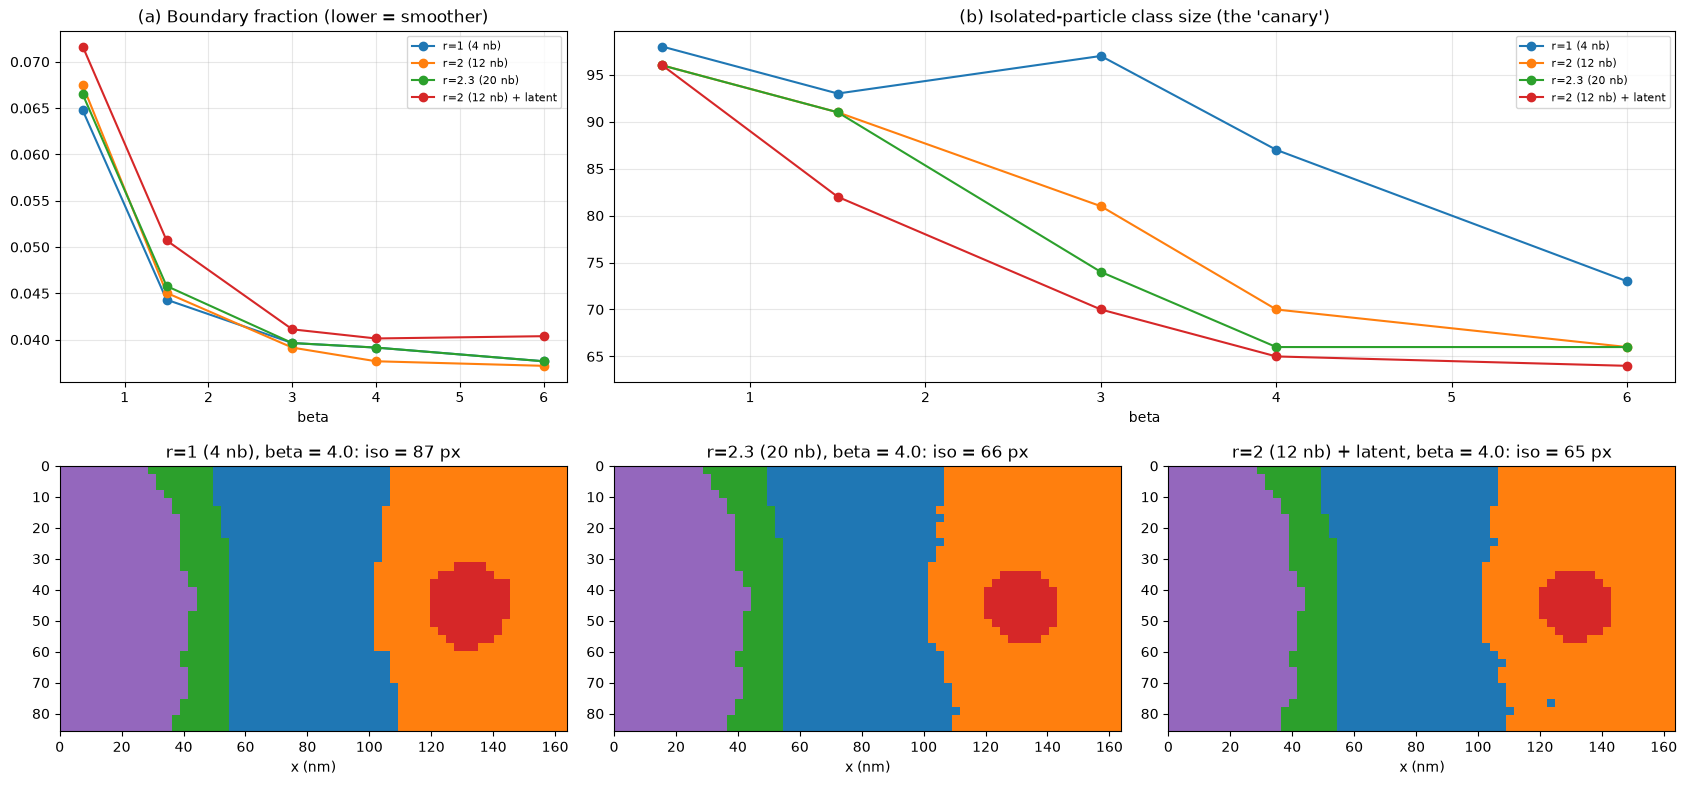

In [84]:
# =====================================================================
# CELL 10: Bigger neighbourhood in the IMAGE, interaction weighted by distance
# =====================================================================
# The data part stays in the latent space Z (same as before).
# What changes is the SPACE part (the Potts prior):
#
#   before: 4 neighbours (up, down, left, right), every edge has weight 1
#   now:    all pixels within a RADIUS (in pixels), weight fades with distance r:
#
#              w_ij = exp( - r_ij^2 / (2 * LENGTH^2) )
#
#           radius 1.0 ->  4 neighbours  (same as before)
#           radius 2.0 -> 12 neighbours
#           radius 2.3 -> 20 neighbours

from sklearn.neighbors import radius_neighbors_graph

LENGTH = 1.5   # pixels: how fast the interaction fades with distance

# (row, column) position of every pixel, in the same order as Z
pixel_xy = np.column_stack([np.repeat(np.arange(H), W),
                            np.tile(np.arange(W), H)]).astype(float)

def spatial_graph(radius, length=LENGTH, use_latent=False, target_weight=4.0):
    """Image neighbours within `radius` pixels, with weights that fade with distance.
    If use_latent=True, the weight also fades when the two spectra (z) are different."""
    # D[i, j] = image distance between pixels i and j (only for pairs within the radius)
    D = radius_neighbors_graph(pixel_xy, radius=radius + 1e-6, mode="distance",
                               include_self=False).tocoo()
    w = np.exp(-D.data ** 2 / (2 * length ** 2))                 # fades with image distance
    if use_latent:
        dz2 = np.sum((Z[D.row] - Z[D.col]) ** 2, axis=1)         # squared latent distance
        w = w * np.exp(-dz2 / (2 * dz2.mean()))                  # fades with spectral difference
    A = sparse.coo_matrix((w, (D.row, D.col)), shape=D.shape).tocsr()
    return A * (target_weight / A.sum(axis=1).mean())            # same total pull as the 4-grid

# ---------------------------------------------------------------------
# 1) Build the graphs we want to compare
# ---------------------------------------------------------------------
configs = {
    "r=1 (4 nb)":            spatial_graph(1.0),
    "r=2 (12 nb)":           spatial_graph(2.0),
    "r=2.3 (20 nb)":         spatial_graph(2.3),
    "r=2 (12 nb) + latent":  spatial_graph(2.0, use_latent=True),
}
for name, A in configs.items():
    print(f"{name:22s}: neighbours per pixel (inside the image) = {np.diff(A.indptr).max()}")

# ---------------------------------------------------------------------
# 2) Scan beta for every graph (about 15 - 30 s in total)
# ---------------------------------------------------------------------
BETAS_10 = [0.5, 1.5, 3.0, 4.0, 6.0]
scan = {name: [] for name in configs}
t0 = time.time()
for name, A in configs.items():
    for b in BETAS_10:
        r = fit_hmrf_graph(Z, b, A, means_gmm, covs_gmm, weights_gmm, labels_gmm)
        r["boundary"] = boundary_fraction(r["labels"].reshape(H, W))
        r["iso_size"] = int(np.sum(r["labels"] == iso_class))
        scan[name].append(r)
print(f"\nscan took {time.time() - t0:.0f} s\n")

print(f"{'graph':>22} | " + " | ".join(f"beta={b:<4}" for b in BETAS_10))
print("-" * 90)
for key, label in [("boundary", "boundary"), ("iso_size", "iso px")]:
    for name in configs:
        vals = " | ".join(f"{r[key]:9.3f}" if key == "boundary" else f"{r[key]:9d}"
                          for r in scan[name])
        print(f"{name:>22} | {vals}   <- {label}")
    print()

# ---------------------------------------------------------------------
# 3) Plots
# ---------------------------------------------------------------------
fig, ax = plt.subplot_mosaic(
    [["bnd", "iso", "iso"],
     ["m0", "m1", "m2"]],
    figsize=(17, 8),
)
for name in configs:
    ax["bnd"].plot(BETAS_10, [r["boundary"] for r in scan[name]], "o-", label=name)
    ax["iso"].plot(BETAS_10, [r["iso_size"] for r in scan[name]], "o-", label=name)
ax["bnd"].set_title("(a) Boundary fraction (lower = smoother)")
ax["iso"].set_title("(b) Isolated-particle class size (the 'canary')")
for key in ["bnd", "iso"]:
    ax[key].set_xlabel("beta")
    ax[key].grid(alpha=0.3)
    ax[key].legend(fontsize=8)

# maps at beta = 4, where the differences are largest
b_show = 4.0
j = BETAS_10.index(b_show)
for a_key, name in zip(["m0", "m1", "m2"],
                       ["r=1 (4 nb)", "r=2.3 (20 nb)", "r=2 (12 nb) + latent"]):
    r = scan[name][j]
    show_labels(ax[a_key], r["labels"].reshape(H, W),
                f"{name}, beta = {b_show}: iso = {r['iso_size']} px")

plt.tight_layout()
plt.show()

scan took 15 s

  K | beta | boundary | uncertainty | iso px | ARI vs GMM
----------------------------------------------------------
 10 |  0.5 |    0.081 |       0.059 |     99 |      0.919
 10 |  1.0 |    0.097 |       0.030 |     98 |      0.919
 10 |  2.0 |    0.097 |       0.016 |     95 |      0.903
 10 |  4.0 |    0.099 |       0.005 |     92 |      0.888
 30 |  0.5 |    0.091 |       0.054 |     99 |      0.860
 30 |  1.0 |    0.100 |       0.034 |     99 |      0.858
 30 |  2.0 |    0.105 |       0.016 |     97 |      0.856
 30 |  4.0 |    0.110 |       0.008 |     96 |      0.851
 60 |  0.5 |    0.091 |       0.058 |     99 |      0.867
 60 |  1.0 |    0.099 |       0.039 |     99 |      0.842
 60 |  2.0 |    0.107 |       0.022 |     98 |      0.859
 60 |  4.0 |    0.111 |       0.012 |     96 |      0.847
GMM | 0.0  |    0.100 |       0.112 |     99 |      1.000


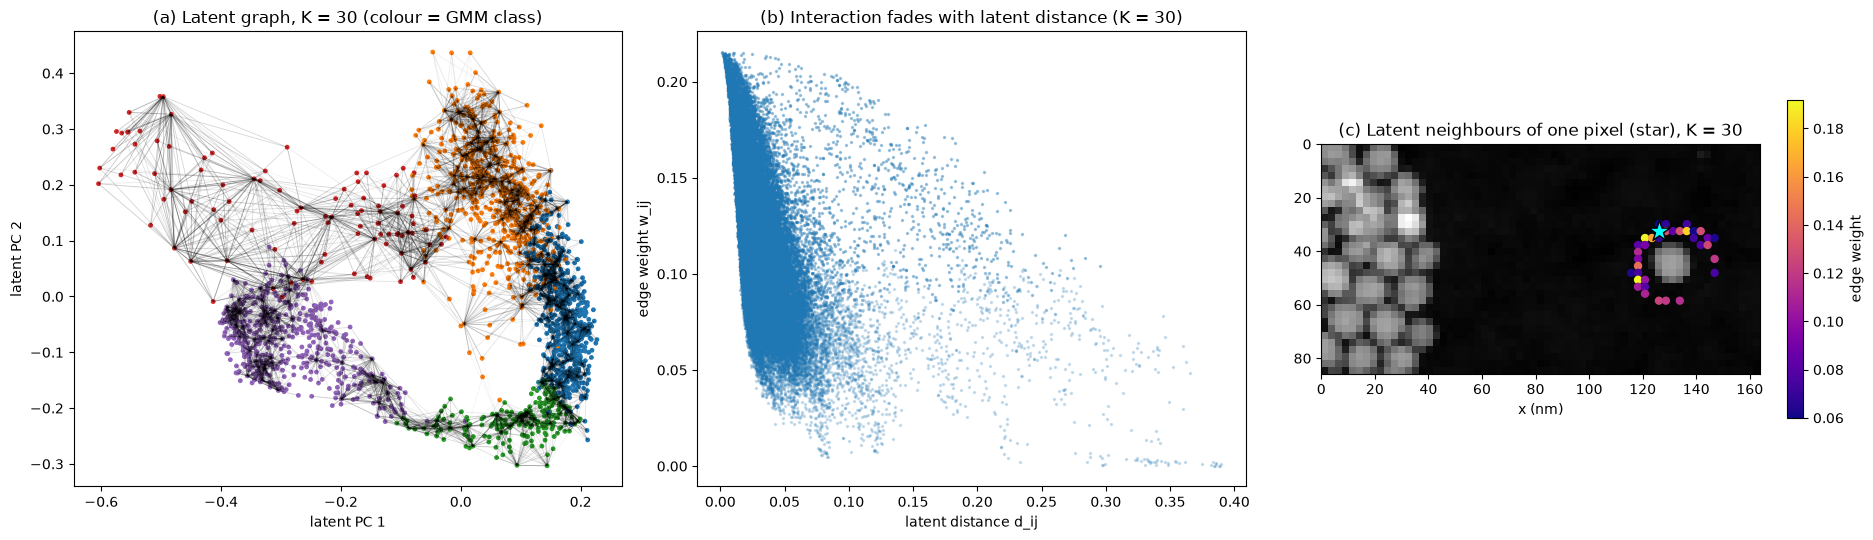

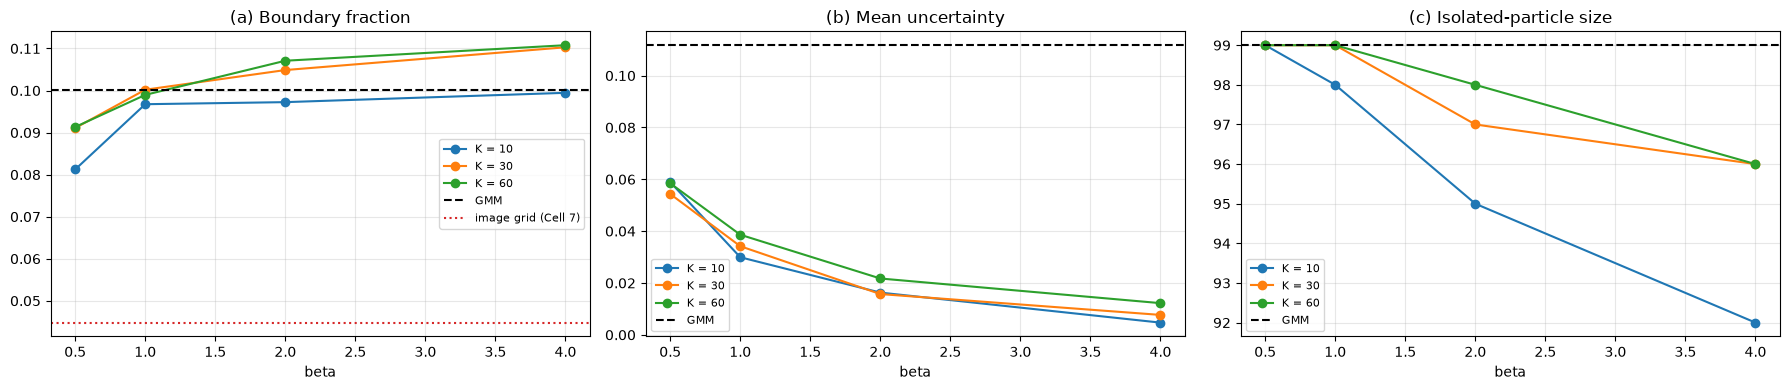

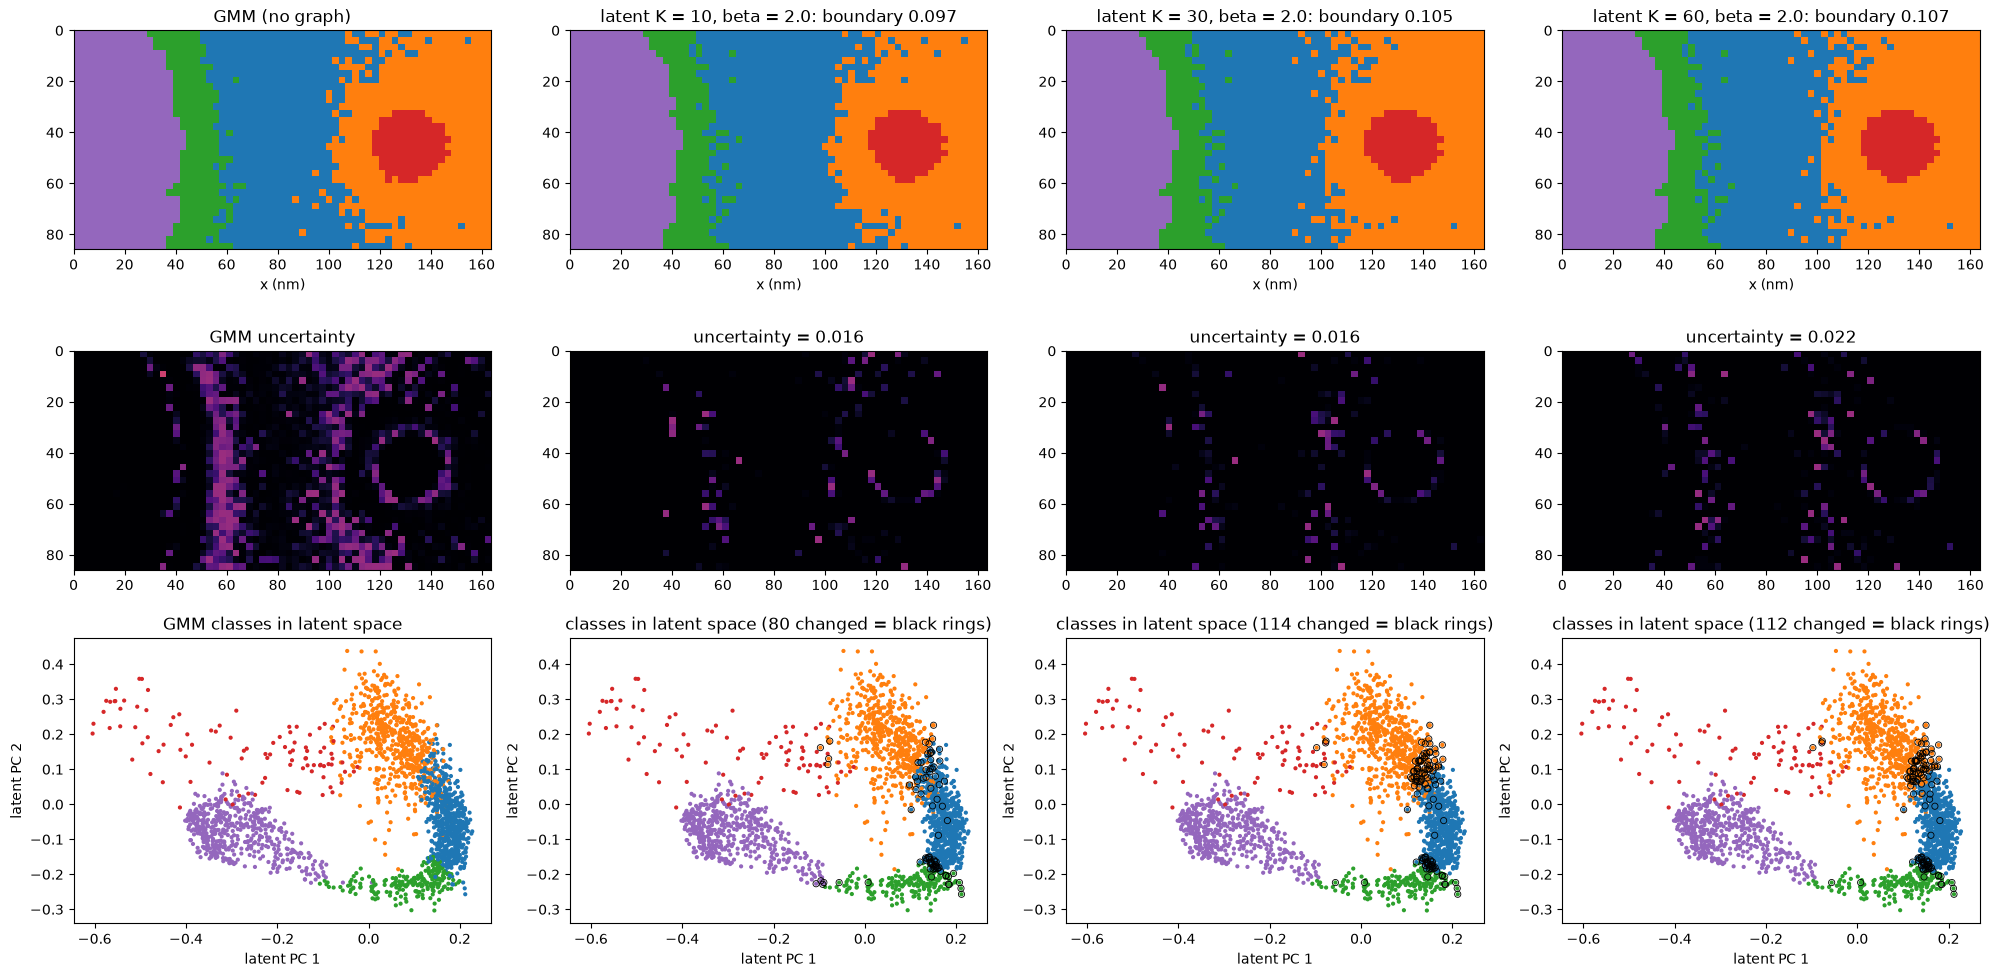

In [85]:
# =====================================================================
# CELL 11: MRF ONLY in the latent space, many neighbours, distance-weighted
# =====================================================================
# Graph: every pixel is connected to its K nearest pixels in the LATENT space Z
#        (NOT in the image). K is large here: 10, 30, 60.
# Weight of an edge: fades with the latent distance d_ij,
#
#        w_ij = exp( - d_ij^2 / (sigma_i * sigma_j) )
#
#        sigma_i = distance from pixel i to its K-th neighbour ("local scale"),
#        so "close" is measured relative to how crowded that part of Z is.
#
#
# Needs from earlier cells: Z, means_gmm, covs_gmm, weights_gmm, labels_gmm,
# fit_hmrf_graph (Cell 9), boundary_fraction, show_labels, iso_class, cmap_cls.

from sklearn.decomposition import PCA
from matplotlib.collections import LineCollection

def latent_knn_graph_weighted(Z, k, target_weight=4.0):
    """K-nearest-neighbour graph in Z with Gaussian weights (local scaling)."""
    D = kneighbors_graph(Z, n_neighbors=k, mode="distance", include_self=False)  # D[i, j] = distance
    sigma = D.max(axis=1).toarray().ravel()           # distance to the K-th neighbour
    D = D.tocoo()
    w = np.exp(-D.data ** 2 / (sigma[D.row] * sigma[D.col]))
    A = sparse.coo_matrix((w, (D.row, D.col)), shape=D.shape).tocsr()
    A = A.maximum(A.T)                                # symmetric: i~j means j~i
    return A * (target_weight / A.sum(axis=1).mean()) # same total pull as the 4-grid

# ---------------------------------------------------------------------
# 1) Build the graphs and run the HMRF for several K and beta
# ---------------------------------------------------------------------
K_LIST = [10, 30, 60]
BETAS_11 = [0.5, 1.0, 2.0, 4.0]

latent_graphs = {k: latent_knn_graph_weighted(Z, k) for k in K_LIST}
latent_scan = {}          # latent_scan[(k, beta)] = result dictionary
t0 = time.time()
for k, A in latent_graphs.items():
    for b in BETAS_11:
        r = fit_hmrf_graph(Z, b, A, means_gmm, covs_gmm, weights_gmm, labels_gmm)
        r["boundary"] = boundary_fraction(r["labels"].reshape(H, W))
        r["iso_size"] = int(np.sum(r["labels"] == iso_class))
        r["ari_gmm"] = adjusted_rand_score(labels_gmm, r["labels"])
        latent_scan[(k, b)] = r
print(f"scan took {time.time() - t0:.0f} s\n")

print(f"{'K':>3} | {'beta':>4} | {'boundary':>8} | {'uncertainty':>11} | {'iso px':>6} | {'ARI vs GMM':>10}")
print("-" * 58)
for (k, b), r in latent_scan.items():
    print(f"{k:3d} | {b:4.1f} | {r['boundary']:8.3f} | {r['entropy'].mean():11.3f} | "
          f"{r['iso_size']:6d} | {r['ari_gmm']:10.3f}")
print(f"GMM | 0.0  | {boundary_fraction(map_gmm):8.3f} | {entropy_gmm.mean():11.3f} | "
      f"{np.sum(labels_gmm == iso_class):6d} |      1.000")

# ---------------------------------------------------------------------
# 2) FIGURE 1: what the latent graph looks like
# ---------------------------------------------------------------------
# Z has 4 numbers per pixel. To draw it, we project it to 2D with PCA.
# (PCA here is only for drawing; the model still uses the full 4D Z.)
K_SHOW = 30
A_show = latent_graphs[K_SHOW]
Z2 = PCA(n_components=2).fit_transform(Z)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))

# (a) the graph in latent space: points = pixels, lines = edges (darker = stronger)
rng_plot = np.random.default_rng(1)
some = rng_plot.choice(H * W, size=250, replace=False)     # draw edges of 250 pixels only
A_coo = A_show[some].tocoo()
segments = np.stack([Z2[some[A_coo.row]], Z2[A_coo.col]], axis=1)
w_line = A_coo.data / A_coo.data.max()
ax[0].add_collection(LineCollection(segments, colors=[(0, 0, 0, 0.35 * a) for a in w_line],
                                    linewidths=0.6))
ax[0].scatter(Z2[:, 0], Z2[:, 1], c=labels_gmm, cmap=cmap_cls, vmin=-0.5, vmax=9.5, s=6)
ax[0].set_title(f"(a) Latent graph, K = {K_SHOW} (colour = GMM class)")
ax[0].set_xlabel("latent PC 1")
ax[0].set_ylabel("latent PC 2")

# (b) edge weights vs latent distance -> shows the interaction really fades
D_show = kneighbors_graph(Z, n_neighbors=K_SHOW, mode="distance").tocoo()
A_dir = A_show.tocsr()
w_edges = np.asarray(A_dir[D_show.row, D_show.col]).ravel()
ax[1].scatter(D_show.data, w_edges, s=2, alpha=0.2)
ax[1].set_xlabel("latent distance d_ij")
ax[1].set_ylabel("edge weight w_ij")
ax[1].set_title(f"(b) Interaction fades with latent distance (K = {K_SHOW})")

# (c) the neighbours of one pixel, shown IN THE IMAGE, coloured by weight
p = int(np.flatnonzero(labels_gmm == iso_class)[0])        # a pixel of the isolated particle
nb = A_show[p].indices
wt = A_show[p].data
ax[2].imshow(image, cmap="gray", extent=extent)
sc = ax[2].scatter((nb % W + 0.5) * scale, (nb // W + 0.5) * scale, c=wt, cmap="plasma", s=25)
ax[2].scatter((p % W + 0.5) * scale, (p // W + 0.5) * scale, marker="*", s=250,
              color="cyan", edgecolor="k")
fig.colorbar(sc, ax=ax[2], shrink=0.7, label="edge weight")
ax[2].set_title(f"(c) Latent neighbours of one pixel (star), K = {K_SHOW}")
ax[2].set_xlabel("x (nm)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3) FIGURE 2: curves vs beta for each K
# ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for k in K_LIST:
    rows = [latent_scan[(k, b)] for b in BETAS_11]
    ax[0].plot(BETAS_11, [r["boundary"] for r in rows], "o-", label=f"K = {k}")
    ax[1].plot(BETAS_11, [r["entropy"].mean() for r in rows], "o-", label=f"K = {k}")
    ax[2].plot(BETAS_11, [r["iso_size"] for r in rows], "o-", label=f"K = {k}")
ax[0].axhline(boundary_fraction(map_gmm), color="k", ls="--", label="GMM")
ax[0].axhline(boundary_fraction(map_hmrf), color="tab:red", ls=":", label=f"image grid (Cell 7)")
ax[1].axhline(entropy_gmm.mean(), color="k", ls="--", label="GMM")
ax[2].axhline(np.sum(labels_gmm == iso_class), color="k", ls="--", label="GMM")
for a, t in zip(ax, ["(a) Boundary fraction", "(b) Mean uncertainty", "(c) Isolated-particle size"]):
    a.set_title(t)
    a.set_xlabel("beta")
    a.grid(alpha=0.3)
    a.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4) FIGURE 3: maps for each K at one beta
# ---------------------------------------------------------------------
B_SHOW = 2.0
fig, ax = plt.subplots(3, len(K_LIST) + 1, figsize=(5 * (len(K_LIST) + 1), 10))

# first column: GMM for reference
show_labels(ax[0, 0], map_gmm, "GMM (no graph)")
ax[1, 0].imshow(entropy_gmm, cmap="magma", vmin=0, vmax=np.log(N_CLUSTERS), extent=extent)
ax[1, 0].set_title("GMM uncertainty")
ax[2, 0].scatter(Z2[:, 0], Z2[:, 1], c=labels_gmm, cmap=cmap_cls, vmin=-0.5, vmax=9.5, s=4)
ax[2, 0].set_title("GMM classes in latent space")

for j, k in enumerate(K_LIST, start=1):
    r = latent_scan[(k, B_SHOW)]
    show_labels(ax[0, j], r["labels"].reshape(H, W),
                f"latent K = {k}, beta = {B_SHOW}: boundary {r['boundary']:.3f}")
    ax[1, j].imshow(r["entropy"].reshape(H, W), cmap="magma", vmin=0,
                    vmax=np.log(N_CLUSTERS), extent=extent)
    ax[1, j].set_title(f"uncertainty = {r['entropy'].mean():.3f}")
    # classes in latent space: black rings = pixels that changed class vs GMM
    moved = r["labels"] != labels_gmm
    ax[2, j].scatter(Z2[:, 0], Z2[:, 1], c=r["labels"], cmap=cmap_cls, vmin=-0.5, vmax=9.5, s=4)
    ax[2, j].scatter(Z2[moved, 0], Z2[moved, 1], facecolors="none", edgecolors="k", s=20, lw=0.6)
    ax[2, j].set_title(f"classes in latent space ({moved.sum()} changed = black rings)")
for a in ax[2]:
    a.set_xlabel("latent PC 1")
    a.set_ylabel("latent PC 2")
plt.tight_layout()
plt.show()



## <font color="purple">**2.**</font> Explore the Spectra

Before clustering, always look at the data.

The structural image tells us **where** each spectrum was measured.  
The spectra tell us **what the local EELS response looks like**.

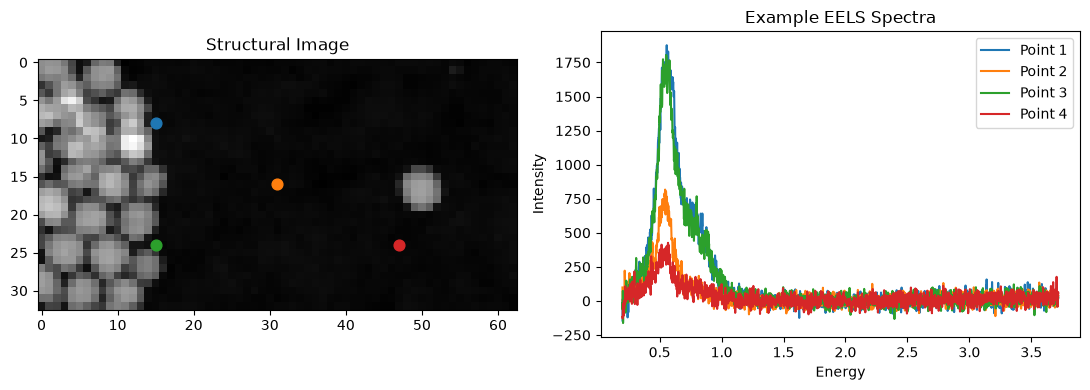

In [6]:
# Pick a few example locations
positions = [
    (H // 4, W // 4),
    (H // 2, W // 2),
    (3 * H // 4, W // 4),
    (3 * H // 4, 3 * W // 4),
]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

for i, (y, x) in enumerate(positions):
    ax[0].scatter(x, y, s=60)
    ax[1].plot(energy, spectra[y, x], label=f"Point {i + 1}")

ax[1].set_title("Example EELS Spectra")
ax[1].set_xlabel("Energy")
ax[1].set_ylabel("Intensity")
ax[1].legend()

plt.tight_layout()
plt.show()

## <font color="purple">**3.**</font> Convert the Spectral Image into a Data Matrix

Clustering algorithms expect a table:

- **rows** = samples
- **columns** = features

For EELS:

- one **pixel** = one sample
- one **energy channel** = one feature

So we reshape

(H, W, N<sub>E</sub>) &rarr; (H &times; W, N<sub>E</sub>)

In [7]:
X = spectra.reshape(-1, N_E)

print("Clustering matrix:", X.shape)
print("Number of spectra:", X.shape[0])
print("Features per spectrum:", X.shape[1])

Clustering matrix: (2079, 4322)
Number of spectra: 2079
Features per spectrum: 4322


## <font color="purple">**4.**</font> Standardize the Spectral Features

Different energy channels can have very different intensity scales.

Standardization transforms each feature approximately to:

z = <span style="display:inline-block; text-align:center;">
  <span style="border-bottom:1px solid; display:block;">x - &mu;</span>
  <span style="display:block;">&sigma;</span>
</span>

This prevents a large-intensity energy channel from dominating only because of its numerical scale.

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data:", X_scaled.shape)

Scaled data: (2079, 4322)


# Worked Example

Before the challenge, here is **one complete example**.

We will use:

- **K-Means**
- \(k=3\) clusters
- the full standardized EELS spectrum

K-Means assigns spectra to groups so that spectra inside a cluster are as similar as possible.

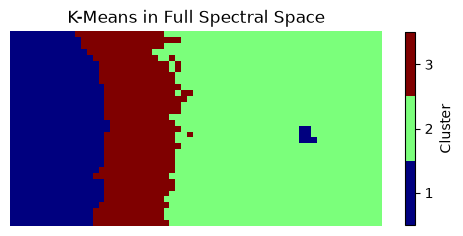

In [9]:
# Example: cluster the full spectra

k = 3

model = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_high = model.fit_predict(X_scaled)

cluster_map_high = labels_high.reshape(H, W) + 1

plt.figure(figsize=(6, 5))

im = plt.imshow(
    cluster_map_high,
    cmap=plt.get_cmap("jet", k),
    vmin=0.5,
    vmax=k + 0.5
)

plt.colorbar(im, ticks=range(1, k + 1), label="Cluster", shrink = 0.5)
plt.title("K-Means in Full Spectral Space")
plt.axis("off")
plt.show()

<h3>What did we just do?</h3>

<p>
Each EELS spectrum originally contained <b>N<sub>E</sub> spectral features</b>.
</p>

<p>
K-Means therefore grouped the spectra directly in an
<b>N<sub>E</sub>-dimensional feature space</b>.
</p>

<p>
The resulting cluster map is our
<b>high-dimensional clustering result</b>.
</p>

<p>
Next, we will reduce the dimensionality of the spectra and ask:
</p>

<p style="font-size:18px;">
<b>Do we recover the same clustering using fewer features?</b>
</p>

# <font color="red">Challenge 1</font> — High-Dimensional Clustering

Choose a number of clusters and cluster the **full standardized spectra**.

Try values such as:

- \(k=2\)
- \(k=3\)
- \(k=4\)
- \(k=5\)

### Question

> Does the cluster map form physically meaningful spatial regions, or does it look fragmented/noisy?

In [10]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

k = 2

# Create Clustering model
# Fit the model to X_scaled
# Store the labels in labels_high
# Reshape labels into cluster_map_high


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

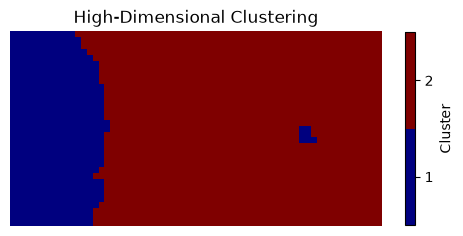

In [11]:
# Plot your result

plt.figure(figsize=(6, 5))

plt.imshow(
    cluster_map_high,
    cmap=plt.get_cmap("jet", k),
    vmin=0.5,
    vmax=k + 0.5
)

plt.colorbar(
    ticks=range(1, k + 1),
    label="Cluster", shrink = .5
)

plt.title("High-Dimensional Clustering")
plt.axis("off")
plt.show()

<h2><font color="purple">5.</font> Dimensional Reduction with PCA</h2>

<p>
EELS spectra can contain a large number of energy channels.
Many of these channels are correlated, meaning they do not all provide completely independent information.
</p>

<p>
<b>Principal Component Analysis (PCA)</b> reduces the dimensionality of the spectra by representing them with a smaller number of new features called <b>principal components</b>.
</p>

<p>
Instead of describing each spectrum using:
</p>

<p style="font-size:18px;">
N<sub>E</sub> spectral features
</p>

<p>
we can describe it using only:
</p>

<p style="font-size:18px;">
PC<sub>1</sub>, PC<sub>2</sub>, ..., PC<sub>n</sub>
</p>

<p>
The goal is to use fewer dimensions while preserving as much of the important spectral variation as possible.
</p>

<p>
This gives us a <b>low-dimensional representation</b> of the original EELS spectra.
</p>

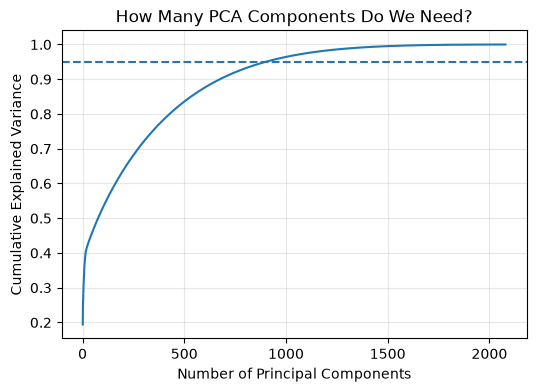

In [12]:
# First inspect how much information PCA keeps

pca_all = PCA()
pca_all.fit(X_scaled)

variance = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(variance) + 1), variance)
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("How Many PCA Components Do We Need?")
plt.grid(alpha=0.3)
plt.show()

# <font color="red">Challenge 2</font> — Low-Dimensional Clustering

Choose a small number of PCA components.

For example:

```python
n_components = 3
```

Then:

1. reduce the spectra with PCA,
2. cluster the reduced data with K-Means,
3. reshape the labels into an image.

### Question

> Can a few PCA components reproduce the structure found using the full spectrum?

In [13]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

n_components = 3

# Run PCA
# X_pca = ...

# Cluster X_pca using the same k
# labels_low = ...

# Reshape labels
# cluster_map_low = ...


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

In [ ]:
# Plot your PCA clustering result

plt.figure(figsize=(6, 5))
plt.imshow(cluster_map_low, cmap="tab10")
plt.colorbar(label="Cluster")
plt.title(f"Clustering after PCA ({n_components} components)")
plt.axis("off")
plt.show()

## <font color="purple">**6.**</font> Compare High- and Low-Dimensional Results

Visual comparison is useful, but cluster labels can be misleading.

For example:

- high-dimensional cluster `0`
- low-dimensional cluster `2`

may represent the **same physical group**.

Therefore, do **not** compare cluster numbers directly.

NameError: name 'cluster_map_low' is not defined

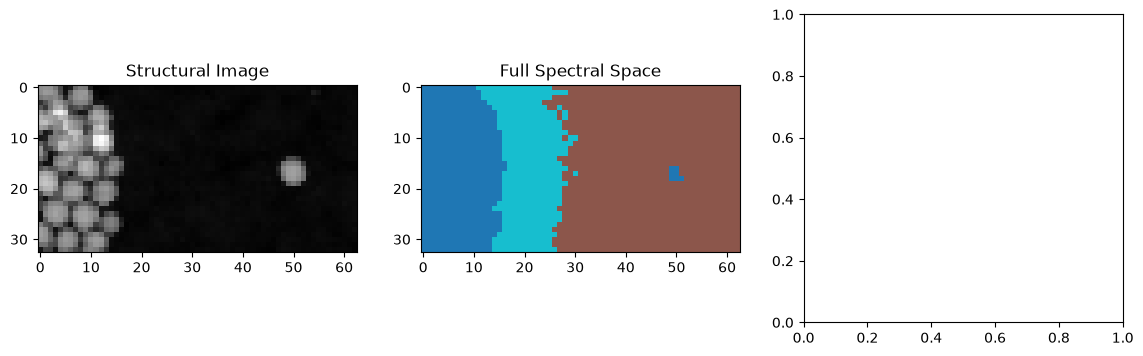

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

ax[1].imshow(cluster_map_high, cmap="tab10")
ax[1].set_title("Full Spectral Space")

ax[2].imshow(cluster_map_low, cmap="tab10")
ax[2].set_title("PCA Space")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# <font color="red">Challenge 3</font> — How Much Do the Labels Overlap?

We need a comparison that is independent of the numerical cluster labels.

We will use the **Adjusted Rand Index (ARI)**.

\[
ARI \approx 1
\]

means the two clusterings assign points to very similar groups.

\[
ARI \approx 0
\]

means their agreement is close to random.

The **contingency matrix** also shows how clusters from one solution map onto clusters from the other.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# Calculate Adjusted Rand Index
# ari = ...

# Calculate overlap / contingency matrix
# overlap = ...


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

print(f"Adjusted Rand Index: {ari:.3f}")
print("\nCluster overlap matrix:")
print(overlap)

<h2><font color="purple">7.</font> What Makes Clustering Good or Bad?</h2>

<p>
In unsupervised clustering, we usually do not have ground-truth labels.
Therefore, we evaluate clustering using <b>internal quality metrics</b>.
</p>

<p>Here we will use two common metrics:</p>

<hr>

<h3>Silhouette Score</h3>

<p>
The Silhouette Score measures how well each point fits within its assigned cluster.
A good point should be:
</p>

<ul>
  <li>close to other points in the <b>same cluster</b></li>
  <li>far from points in <b>neighboring clusters</b></li>
</ul>

<p><b>Range:</b></p>

<p style="font-size:18px;">
-1 &le; S &le; 1
</p>

<ul>
  <li><b>Higher is better</b></li>
  <li>Values near 1 indicate well-separated clusters</li>
  <li>Values near 0 indicate overlapping clusters</li>
  <li>Negative values may indicate poor assignments</li>
</ul>

<hr>

<h3>Davies–Bouldin Score</h3>

<p>
The Davies–Bouldin Score measures how compact the clusters are
and how well separated they are from each other.
</p>

<p><b>Range:</b></p>

<p style="font-size:18px;">
DB &ge; 0
</p>

<ul>
  <li><b>Lower is better</b></li>
  <li>Smaller values indicate compact, well-separated clusters</li>
</ul>

<hr>

<p>
<b>Important:</b> A good numerical clustering score does not automatically mean
that the clusters are physically meaningful.
</p>

<p>
For EELS data, we should also inspect the spatial cluster maps and the average
spectrum of each cluster.
</p>

# <font color="red">Challenge 4</font> — Score Both Clusterings

Calculate the clustering quality in:

1. the full spectral space,
2. the PCA-reduced space.

### Important

Evaluate each set of labels in the **same feature space in which it was clustered**.

In [15]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# High-dimensional clustering
# sil_high = ...
# db_high = ...

# Low-dimensional clustering
# sil_low = ...
# db_low = ...


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

print("Full spectral space")
print(f"  Silhouette:      {sil_high:.3f}")
print(f"  Davies-Bouldin:  {db_high:.3f}")

print("\nPCA space")
print(f"  Silhouette:      {sil_low:.3f}")
print(f"  Davies-Bouldin:  {db_low:.3f}")

Full spectral space


NameError: name 'sil_high' is not defined

## <font color="purple">**8.**</font> Inspect the Average Spectrum of Each Cluster

A clustering map is much easier to interpret if the clusters also have distinct spectral signatures.

For every cluster, calculate the **mean EELS spectrum**.

### Question

> Do the clusters differ in peak intensity, peak position, spectral shape, or background?

In [ ]:
# Example helper function

def plot_cluster_spectra(X, labels, energy):
    for label in np.unique(labels):
        mean_spectrum = X[labels == label].mean(axis=0)
        plt.plot(energy, mean_spectrum, label=f"Cluster {label}")

    plt.xlabel("Energy")
    plt.ylabel("Mean EELS Intensity")
    plt.title("Mean Spectrum of Each Cluster")
    plt.legend()
    plt.show()

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# Use the original spectra X, not X_scaled,
# so the plotted spectra remain physically interpretable.

# plot_cluster_spectra(...)


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

# <font color="red">Final Challenge</font> — Find a Good Clustering

Systematically test different choices.

You may change:

- number of clusters \(k\)
- number of PCA components

For each experiment, record:

- \(k\)
- PCA dimensions
- explained variance
- Silhouette score
- Davies–Bouldin score
- ARI compared with the full-space clustering

### Your goal

> Find a low-dimensional representation that gives compact, separated clusters while preserving the grouping found in the original spectral space.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# Suggested experiment:
#
# for n_components in [2, 3, 5, 10]:
#     ...
#
# Try several k values too.
# Store the results and compare them.


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

## Final Discussion

Be ready to explain your result.

### 1. High vs. low dimensional space
Did PCA change the clustering substantially?

### 2. Cluster overlap
Was the ARI high or low? What does that tell you?

### 3. Quality
Which solution had:

- higher Silhouette score?
- lower Davies–Bouldin score?

### 4. Physics
Do the clusters correspond to:

- spatially coherent regions?
- different EELS spectral signatures?
- visible structural regions?

### 5. Complexity
How many PCA components were actually necessary?

---

## <font color="green">Takeaway</font>

A clustering result is not good simply because an algorithm produced labels.

A useful clustering should ideally be:

- **well separated**
- **internally compact**
- **stable under dimensional reduction**
- **spectrally interpretable**
- **spatially or physically meaningful**